### Preparing and analysing time series data

In [305]:
# Get the libraries and set random seed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from scipy import signal
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing 
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL

import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

np.random.seed(42)

#### Data manipulation

In [306]:
# Get the data

db_offshore = pd.read_csv('/Users/kirillkharlashkin/Documents/Hertie Github repos/Watts-next/data/final_offshore_data_2017_2025.csv')
db_onshore = pd.read_csv('/Users/kirillkharlashkin/Documents/Hertie Github repos/Watts-next/data/final_onshore_data_2017_2025.csv')

In [307]:
# Drop excessive columns that are not need for the analysis

db_offshore = db_offshore.drop(columns=['emission', 'emissionfactor', 'year_mon_day', 'full_datetime'])
db_onshore = db_onshore.drop(columns=['emission', 'emissionfactor', 'year_mon_day', 'full_datetime'])

In [308]:
db_offshore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70151 entries, 0 to 70150
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hour               70151 non-null  int64  
 1   wind_dir_avg_10    70151 non-null  float64
 2   wind_speed_h_avg   70151 non-null  float64
 3   wind_speed_avg_10  70151 non-null  float64
 4   air_pressure       70151 non-null  float64
 5   humidity           70151 non-null  float64
 6   capacity           70151 non-null  int64  
 7   volume             70151 non-null  int64  
 8   percentage         70151 non-null  float64
 9   correct_days       70151 non-null  object 
dtypes: float64(6), int64(3), object(1)
memory usage: 5.4+ MB


In [309]:
# Write the function to engineer datetime features

def transform_datetime_features(df, correct_days_column='correct_days', start_date='2017-01-01'):

    df = df.copy()
    
    # Split into 'date' and 'hour'
    df[['date', 'hour']] = df[correct_days_column].str.rsplit('-', n=1, expand=True)
    
    # Create datetime column
    df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'].astype(int) - 1, unit='H')
    
    # Extract month
    df['month'] = df['datetime'].dt.to_period('M').astype(str)
    
    # Calculate week number
    start_date = pd.Timestamp(start_date)
    df['week_number'] = ((df['datetime'] - start_date).dt.days // 7) + 1
    
    return df

In [310]:
# Apply the function to both datasets

db_offshore = transform_datetime_features(db_offshore)
db_onshore = transform_datetime_features(db_onshore)

/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_92598/1621329718.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'].astype(int) - 1, unit='H')
/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_92598/1621329718.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'].astype(int) - 1, unit='H')


In [311]:
# Drop datetime 2025-01-01 and set datetime as index
db_offshore = db_offshore[db_offshore['month'] != '2025-01']
db_onshore = db_onshore[db_onshore['month'] != '2025-01']

db_offshore.set_index('datetime', inplace=True)
db_onshore.set_index('datetime', inplace=True)

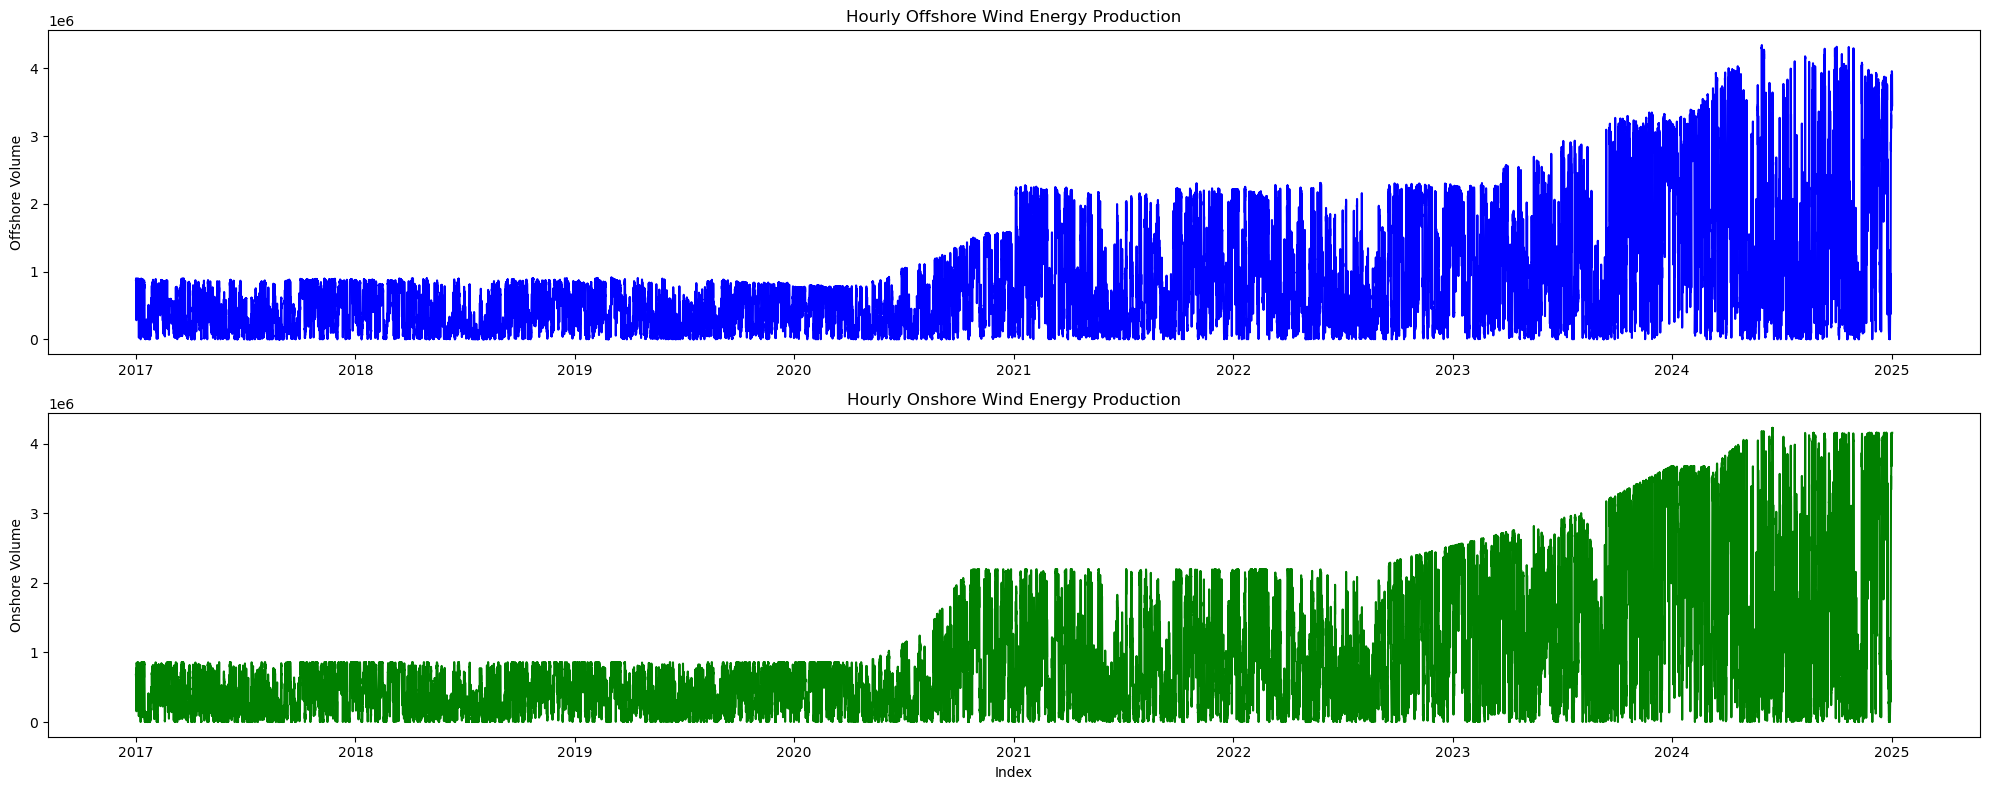

In [312]:
# Make two plots with the label variable

plt.figure(figsize=(20, 8))

# Offshore
plt.subplot(2, 1, 1)  # (nrows=2, ncols=1, index=1)
plt.plot(db_offshore.index, db_offshore['volume'], color='blue')
plt.title('Hourly Offshore Wind Energy Production')
plt.ylabel('Offshore Volume')

# Onshore
plt.subplot(2, 1, 2)  # (nrows=2, ncols=1, index=2)
plt.plot(db_onshore.index, db_onshore['volume'], color='green')
plt.title('Hourly Onshore Wind Energy Production')
plt.ylabel('Onshore Volume')
plt.xlabel('Index')

plt.tight_layout()
plt.show()

#### Time series analysis

##### Seasonal decomposition

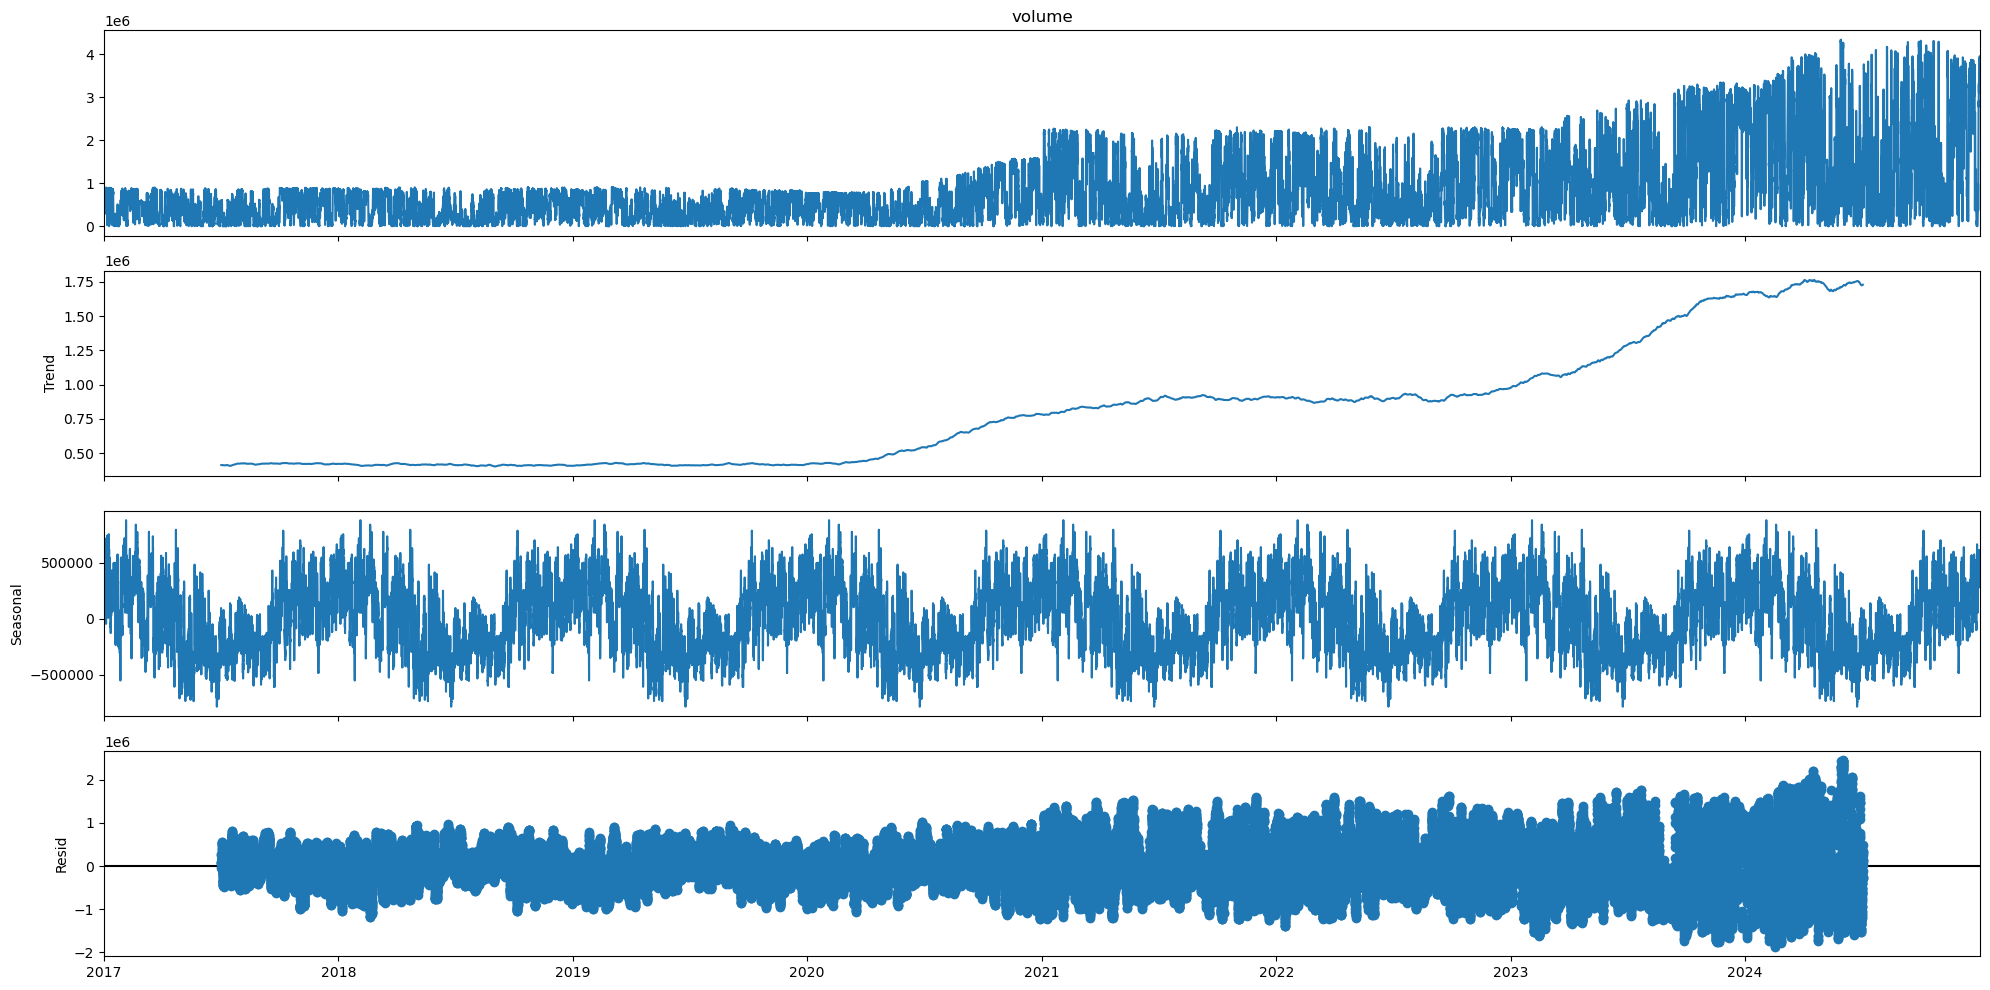

In [313]:
# Check for trend and seasonality for offshore data

decomposition_offshore = seasonal_decompose(db_offshore['volume'], 
                                 model='additive', 
                                 period=8760)  # Annual seasonality
fig = decomposition_offshore.plot()
fig.set_size_inches(20, 10)
plt.tight_layout()
plt.show()

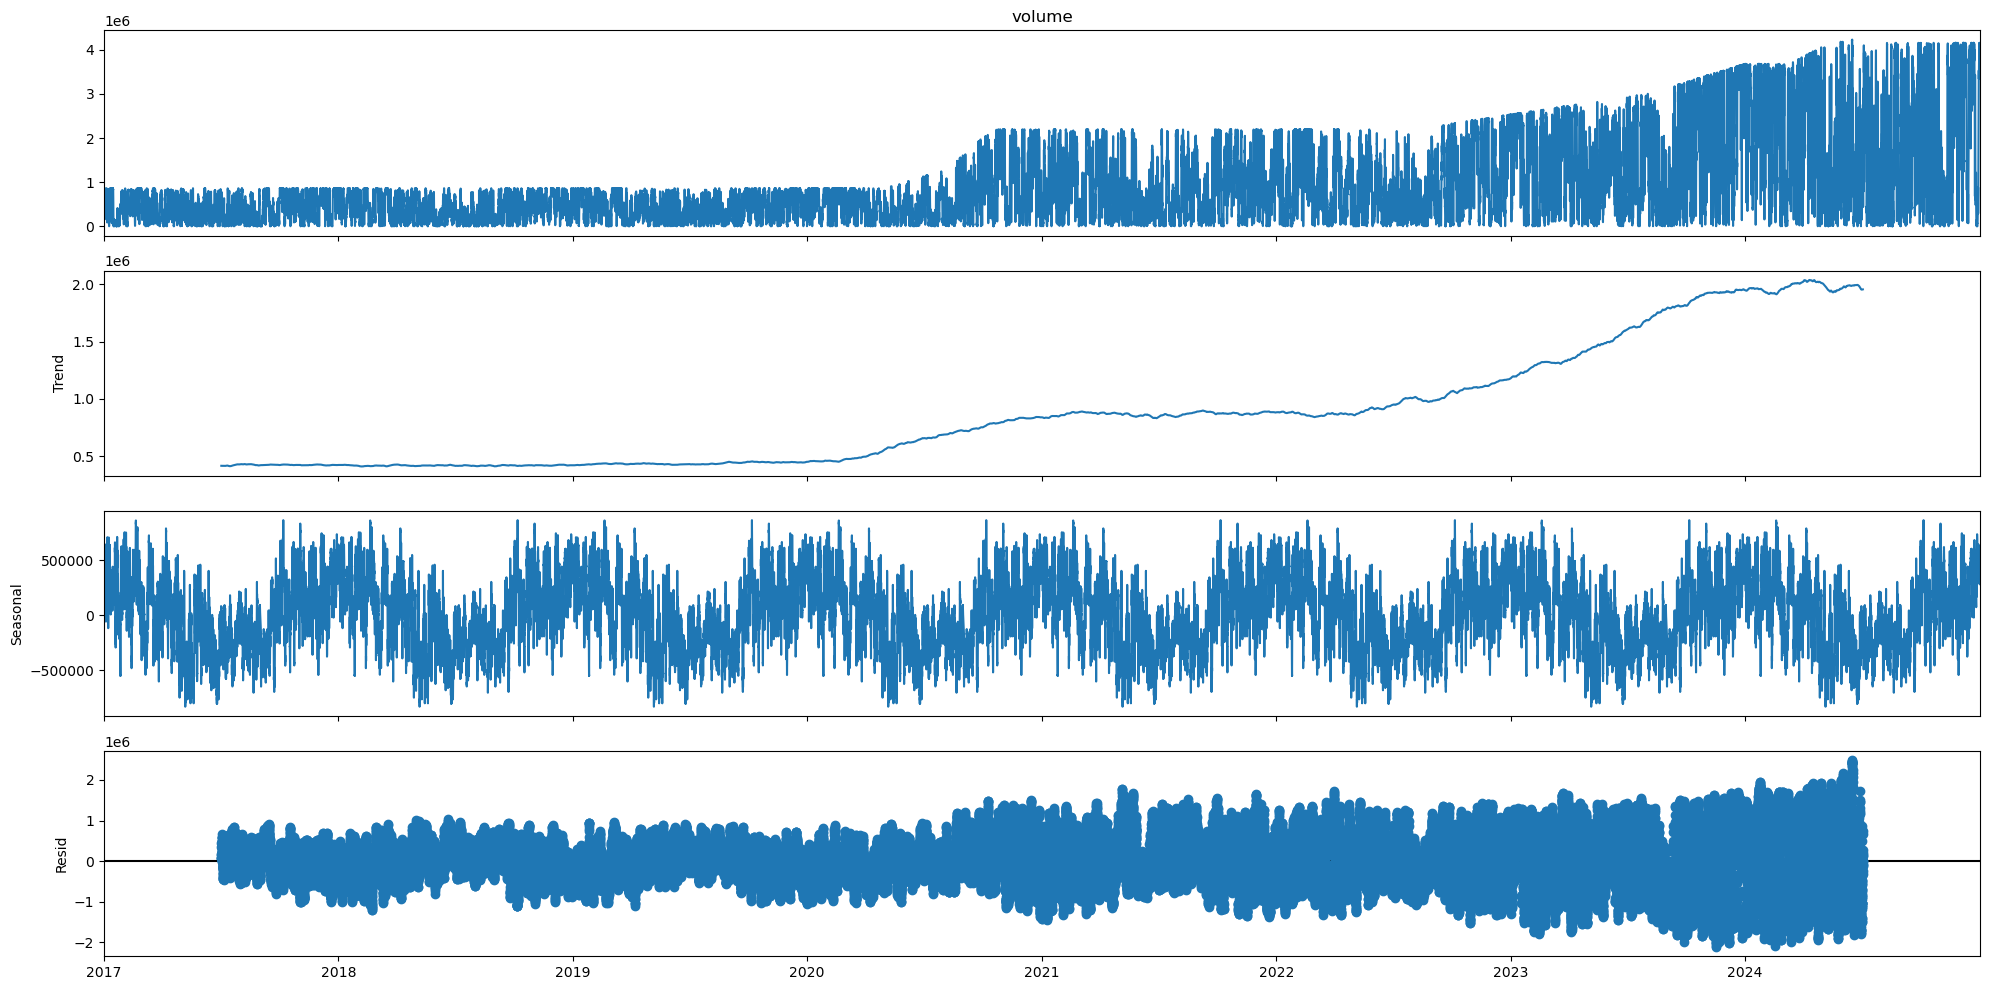

In [314]:
# Check for trend and seasonality for onshore data

decomposition_onshore = seasonal_decompose(db_onshore['volume'], 
                                 model='additive', 
                                 period=8760)  # Annual seasonality
fig = decomposition_onshore.plot()
fig.set_size_inches(20, 10)
plt.tight_layout()
plt.show()

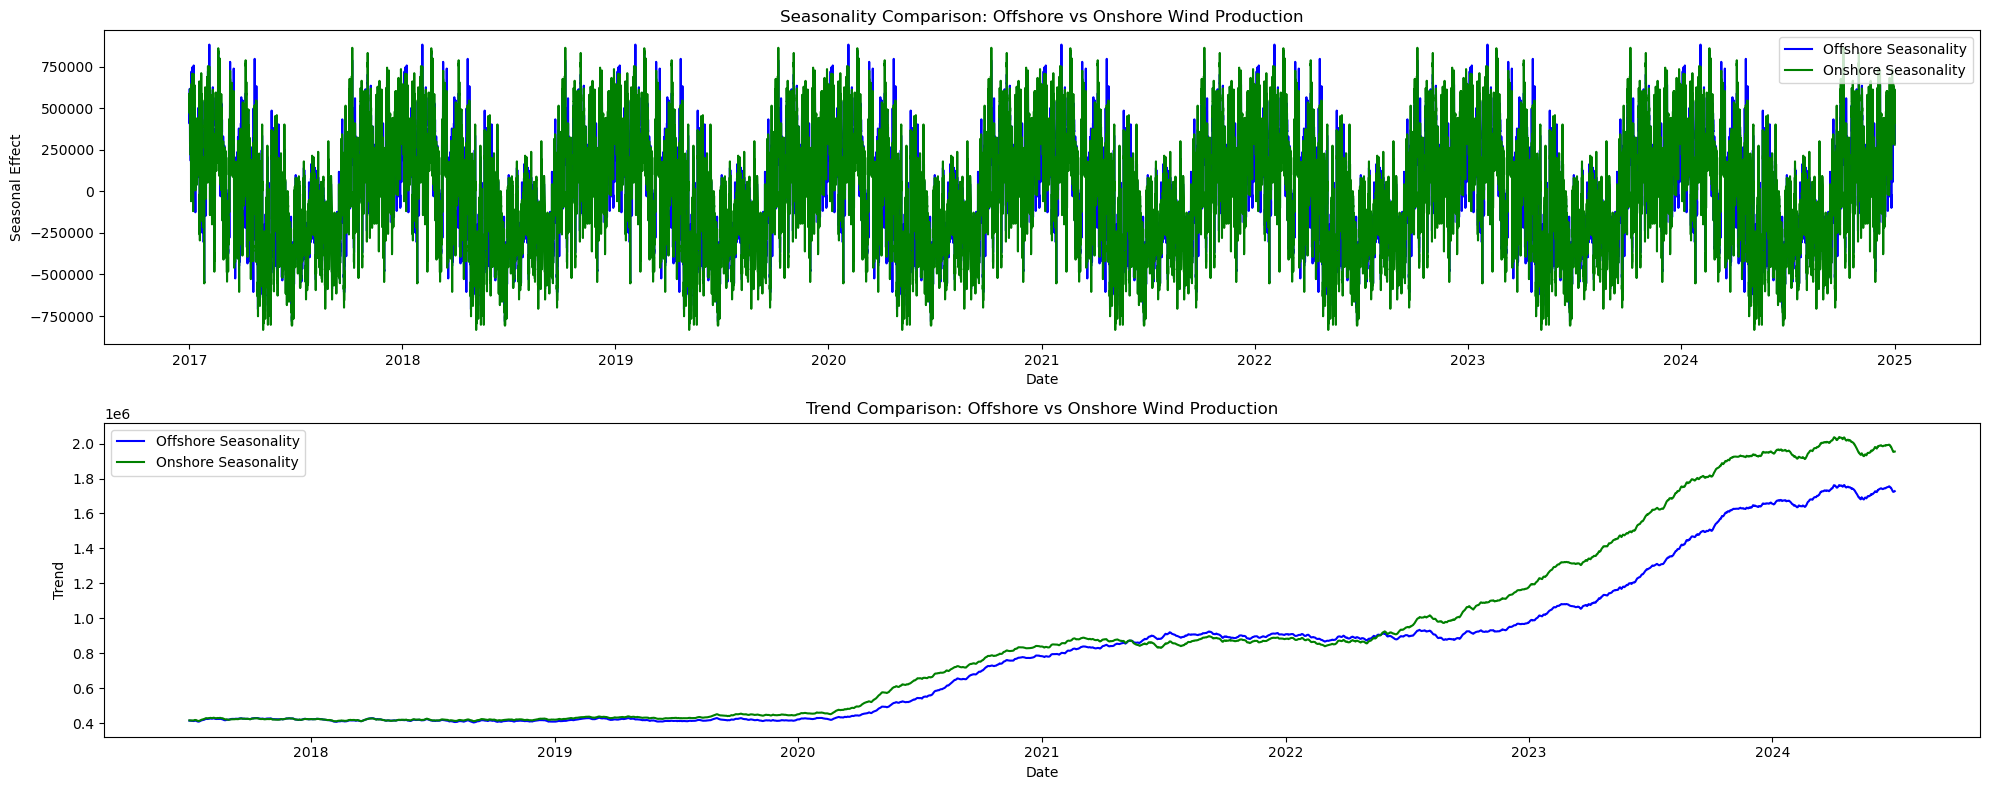

In [315]:
# Compare trend and seasonality for offshore and onshore data

decomp_offshore = seasonal_decompose(db_offshore['volume'], period=8760)
decomp_onshore = seasonal_decompose(db_onshore['volume'], period=8760)

plt.figure(figsize=(20, 8))

# Seasonal
plt.subplot(2, 1, 1)
plt.plot(decomp_offshore.seasonal, label='Offshore Seasonality', color='blue')
plt.plot(decomp_onshore.seasonal, label='Onshore Seasonality', color='green')
plt.title('Seasonality Comparison: Offshore vs Onshore Wind Production')
plt.xlabel('Date')
plt.ylabel('Seasonal Effect')
plt.legend()

# Trend
plt.subplot(2, 1, 2)
plt.plot(decomp_offshore.trend, label='Offshore Seasonality', color='blue')
plt.plot(decomp_onshore.trend, label='Onshore Seasonality', color='green')
plt.title('Trend Comparison: Offshore vs Onshore Wind Production')
plt.xlabel('Date')
plt.ylabel('Trend')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion: Both offshore and onshore datasets share similar trends and seasonality.**

•	Strong trend starting in 2020.

•	Clear seasonality across the entire period.

•	Some heteroskedasticity (changing variance) in residuals post-2022.

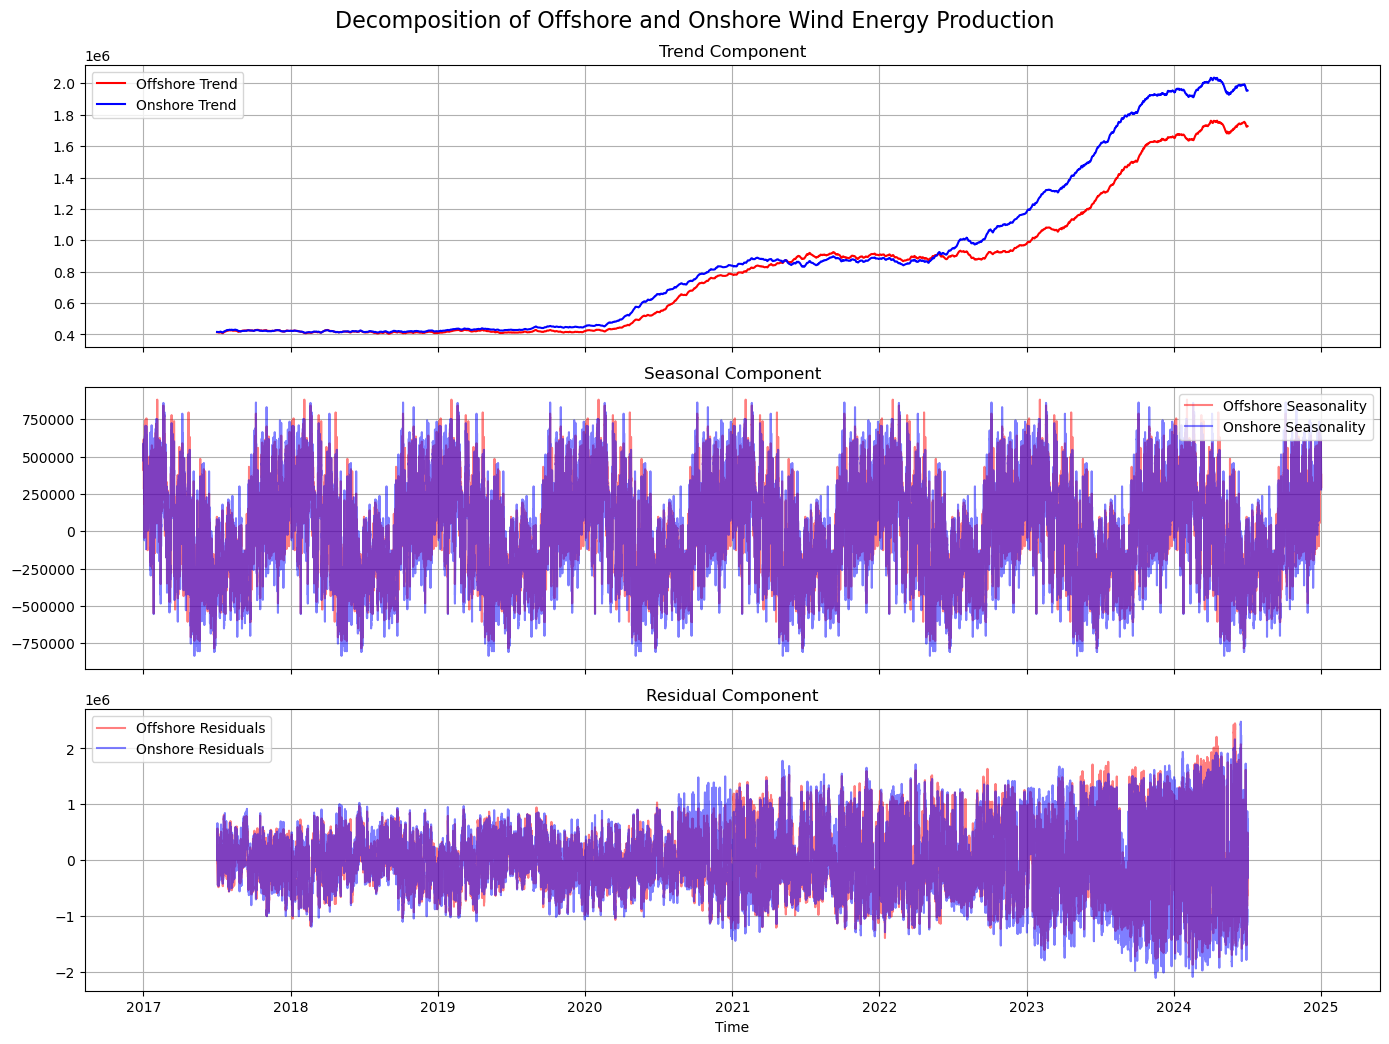

In [316]:
# Perform decomposition
decomp_offshore = seasonal_decompose(db_offshore['volume'], model='additive', period=8760)
decomp_onshore = seasonal_decompose(db_onshore['volume'], model='additive', period=8760)

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot Trend
axs[0].plot(decomp_offshore.trend, label='Offshore Trend', color='red')
axs[0].plot(decomp_onshore.trend, label='Onshore Trend', color='blue')
axs[0].set_title('Trend Component')
axs[0].legend()
axs[0].grid(True)

# Plot Seasonality
axs[1].plot(decomp_offshore.seasonal, label='Offshore Seasonality', color='red', alpha=0.5)
axs[1].plot(decomp_onshore.seasonal, label='Onshore Seasonality', color='blue', alpha=0.5)
axs[1].set_title('Seasonal Component')
axs[1].legend()
axs[1].grid(True)

# Plot Residuals
axs[2].plot(decomp_offshore.resid, label='Offshore Residuals', color='red', alpha=0.5)
axs[2].plot(decomp_onshore.resid, label='Onshore Residuals', color='blue', alpha=0.5)
axs[2].set_title('Residual Component')
axs[2].legend()
axs[2].grid(True)

# Formatting
plt.tight_layout()
plt.xlabel('Time')
plt.suptitle('Decomposition of Offshore and Onshore Wind Energy Production', fontsize=16, y=1.02)
plt.show()

##### Periodograms

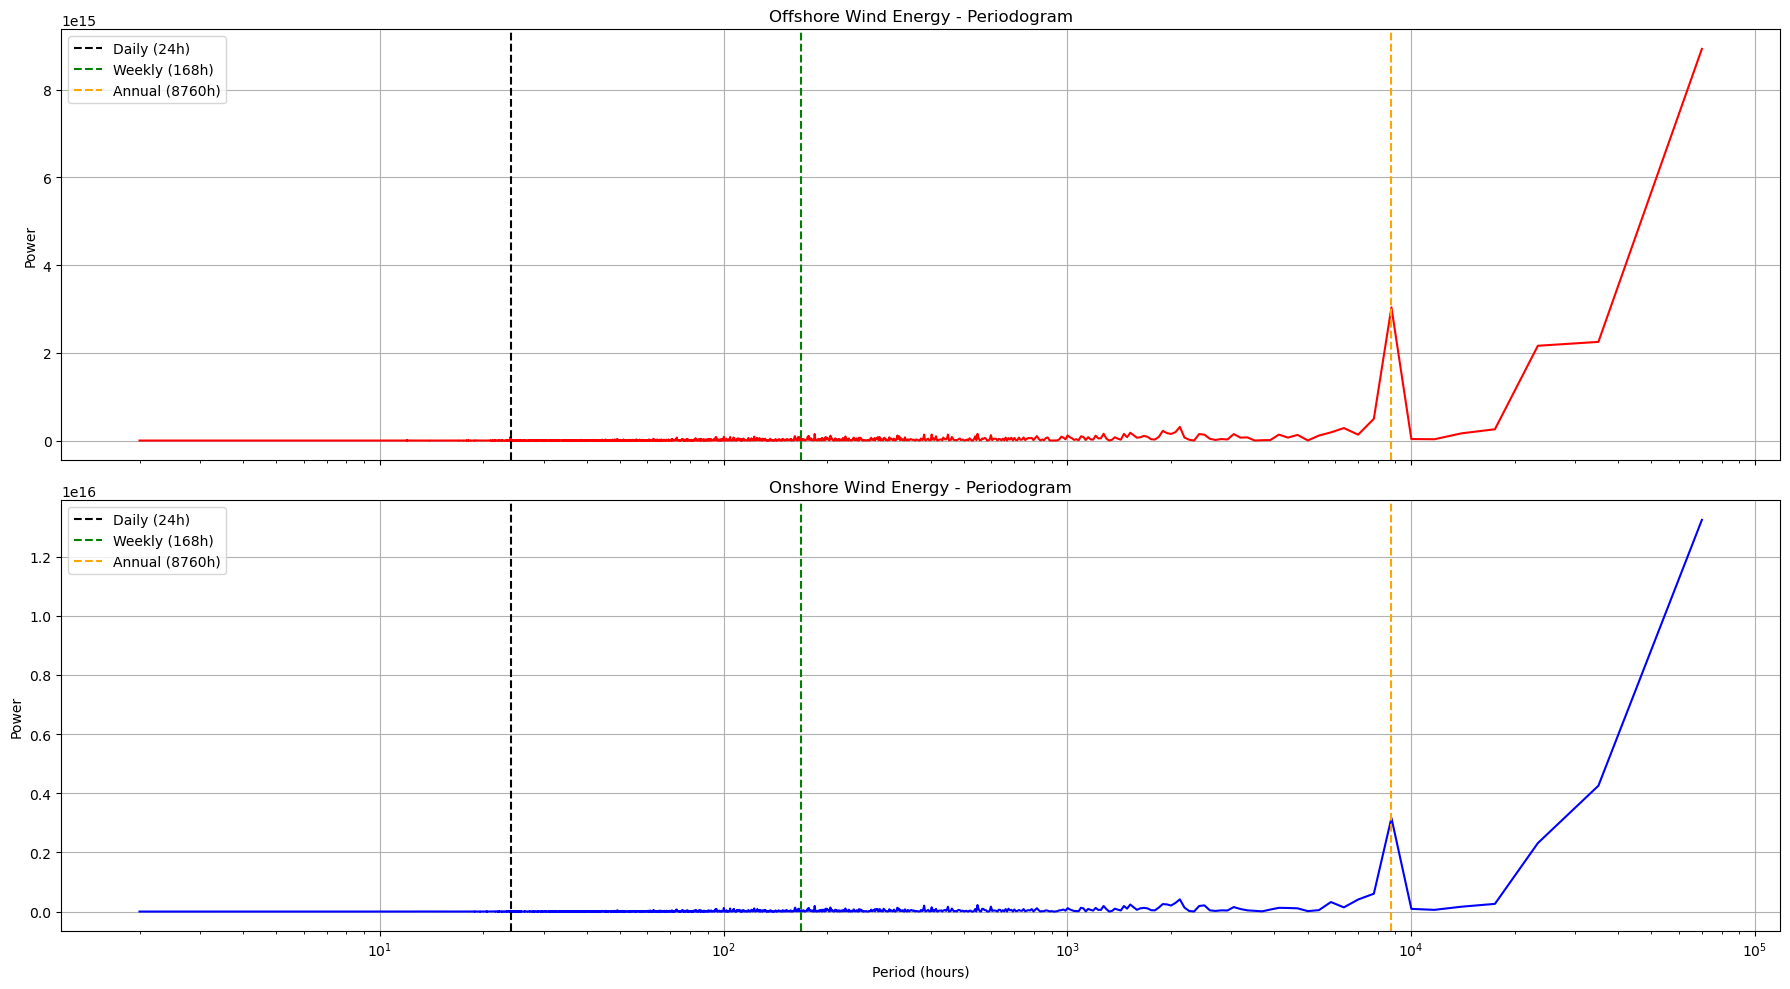

In [317]:
# Compute periodograms
f_offshore, Pxx_offshore = signal.periodogram(db_offshore['volume'].values, fs=1)  # hourly
f_onshore, Pxx_onshore = signal.periodogram(db_onshore['volume'].values, fs=1)

# Convert frequency to periods (skip f=0)
periods_offshore = 1 / f_offshore[1:]
power_offshore = Pxx_offshore[1:]

periods_onshore = 1 / f_onshore[1:]
power_onshore = Pxx_onshore[1:]

# Plot
fig, axs = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Offshore
axs[0].plot(periods_offshore, power_offshore, color='red')
axs[0].set_title('Offshore Wind Energy - Periodogram')
axs[0].set_ylabel('Power')
axs[0].set_xscale('log')
axs[0].axvline(x=24, color='black', linestyle='--', label='Daily (24h)')
axs[0].axvline(x=168, color='green', linestyle='--', label='Weekly (168h)')
axs[0].axvline(x=8760, color='orange', linestyle='--', label='Annual (8760h)')
axs[0].grid(True)
axs[0].legend()

# Onshore
axs[1].plot(periods_onshore, power_onshore, color='blue')
axs[1].set_title('Onshore Wind Energy - Periodogram')
axs[1].set_xlabel('Period (hours)')
axs[1].set_ylabel('Power')
axs[1].set_xscale('log')
axs[1].axvline(x=24, color='black', linestyle='--', label='Daily (24h)')
axs[1].axvline(x=168, color='green', linestyle='--', label='Weekly (168h)')
axs[1].axvline(x=8760, color='orange', linestyle='--', label='Annual (8760h)')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

**Conclusions: the periodograms reveals strong annual seasonality.**

•	Strong annual seasonality: The most prominent peak aligns perfectly with the annual (8760h) reference line in blue. This indicates a very strong yearly cycle in wind energy production.

•	Limited daily and weekly patterns: There's little to no significant power at the 24-hour (red) and 168-hour (green) markers. This suggests that daily and weekly cycles have minimal impact on wind energy production.

•	Noise characteristics: The relatively flat profile at shorter periods (left side of graph) suggests that short-term fluctuations in wind production are more random/white noise rather than following predictable patterns.

##### ACF (for seasonality)

The Autocorrelation Function (ACF) plot shows how strongly the time series is correlated with its own lagged values — how today’s value relates to past values (1 hour ago, 2 hours ago, …, 50 lags ago).

In [318]:
# Write ACF function
def plot_acf_series(series, lags=50, title=''):
    plt.figure(figsize=(10, 4))
    plot_acf(series.dropna(), lags=lags)
    plt.title(f"ACF Plot for {title}")
    plt.tight_layout()
    plt.show()

<Figure size 1000x400 with 0 Axes>

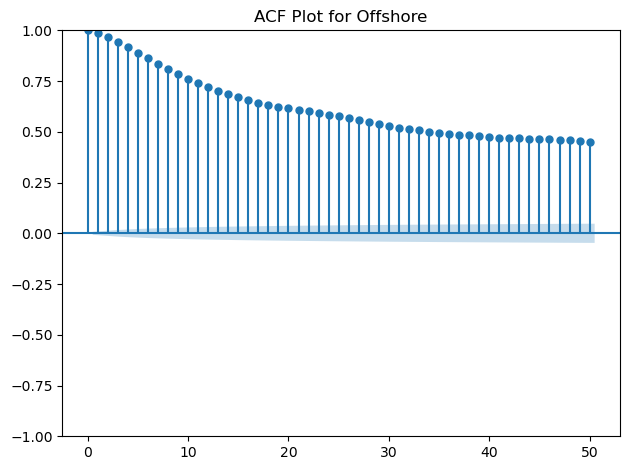

<Figure size 1000x400 with 0 Axes>

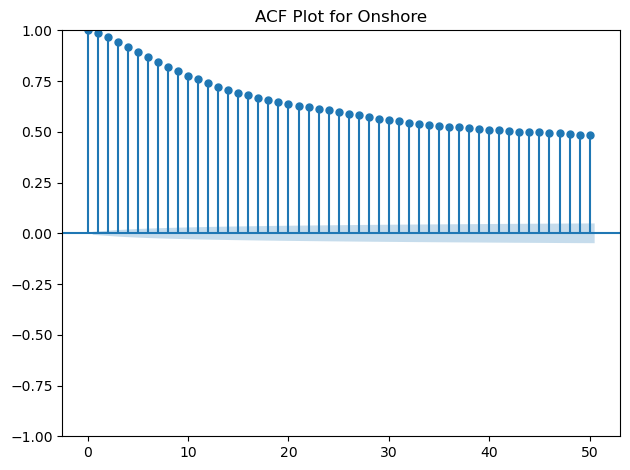

In [319]:
# ACF Plot
plot_acf_series(db_offshore['volume'], title='Offshore')
plot_acf_series(db_onshore['volume'], title='Onshore')

**Conclusions: We have a non-stationary dataset**

•	High autocorrelation at lag 1 (almost 1.0):
    This means today’s value is very strongly related to the previous hour’s value.

•	Slow, gradual decline in autocorrelations across lags:
    This is a typical sign of non-stationarity. The series has a persistent trend or pattern.

•	No sharp cutoff or sudden drop in autocorrelation:
    Suggests the process has long memory — past values continue to influence future ones.

##### Check for constant variance (homoscedasticity)

In [320]:
# Example: assuming your datasets have 'volume' as Y and 'hour', 'month' as predictors

# Offshore
model_offshore = smf.ols('volume ~ hour + month', data=db_offshore).fit()
bp_test_offshore = het_breuschpagan(model_offshore.resid, model_offshore.model.exog)

print("Breusch-Pagan Test (Offshore)")
print(f"LM stat: {bp_test_offshore[0]}, p-value: {bp_test_offshore[1]}")

# Onshore
model_onshore = smf.ols('volume ~ hour + month', data=db_onshore).fit()
bp_test_onshore = het_breuschpagan(model_onshore.resid, model_onshore.model.exog)

print("\nBreusch-Pagan Test (Onshore)")
print(f"LM stat: {bp_test_onshore[0]}, p-value: {bp_test_onshore[1]}")

Breusch-Pagan Test (Offshore)
LM stat: 24297.209597239584, p-value: 0.0

Breusch-Pagan Test (Onshore)
LM stat: 27650.911509329057, p-value: 0.0


**Conclusions: If p < 0.05 → reject null → heteroscedasticity detected**

##### Final remarks: ADF and KPSS tests for overall stationarity

In [321]:


def run_adf_test(series, name=''):
    print(f"\n🔍 ADF Test for {name}:")
    result = adfuller(series.dropna())
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    for key, value in result[4].items():
        print(f"Critical Value {key} : {value:.4f}")
    if result[1] < 0.05:
        print("✅ The series is likely stationary.")
    else:
        print("❌ The series is likely non-stationary.")

def run_kpss_test(series, name=''):
    print(f"\n🔍 KPSS Test for {name}:")
    result = kpss(series.dropna(), regression='c', nlags="auto")
    print(f"KPSS Statistic : {result[0]:.4f}")
    print(f"p-value        : {result[1]:.4f}")
    for key, value in result[3].items():
        print(f"Critical Value {key} : {value:.4f}")
    if result[1] < 0.05:
        print("❌ The series is likely non-stationary.")
    else:
        print("✅ The series is likely stationary.")

In [322]:
run_adf_test(db_onshore['volume'], name='Onshore Volume')
run_kpss_test(db_onshore['volume'], name='Onshore Volume')

run_adf_test(db_offshore['volume'], name='Offshore Volume')
run_kpss_test(db_offshore['volume'], name='Offshore Volume')


🔍 ADF Test for Onshore Volume:
ADF Statistic : -14.8326
p-value       : 0.0000
Critical Value 1% : -3.4304
Critical Value 5% : -2.8616
Critical Value 10% : -2.5668
✅ The series is likely stationary.

🔍 KPSS Test for Onshore Volume:
KPSS Statistic : 25.1178
p-value        : 0.0100
Critical Value 10% : 0.3470
Critical Value 5% : 0.4630
Critical Value 2.5% : 0.5740
Critical Value 1% : 0.7390
❌ The series is likely non-stationary.

🔍 ADF Test for Offshore Volume:


/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_92598/3819418763.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags="auto")


ADF Statistic : -15.5125
p-value       : 0.0000
Critical Value 1% : -3.4304
Critical Value 5% : -2.8616
Critical Value 10% : -2.5668
✅ The series is likely stationary.

🔍 KPSS Test for Offshore Volume:
KPSS Statistic : 23.0480
p-value        : 0.0100
Critical Value 10% : 0.3470
Critical Value 5% : 0.4630
Critical Value 2.5% : 0.5740
Critical Value 1% : 0.7390
❌ The series is likely non-stationary.


/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_92598/3819418763.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags="auto")


##### Overall conclusion

**We have a non-stationary time series data**

*Features of stationary time series data*:

1. **Constant Mean (no trend)**: The mean of the series remains constant over time.

    We have upward trend in both datasets, which is a sign of non-stationarity.

2. **Constant Variance**: The variance of the series remains constant over time.

    We detected heteroscedasticity in variance for both datasets.

3. **Constant autocorrelation structure over time (no seasonality)**: The series does not exhibit any seasonal patterns.
        
    We have strong annual seasonality in both datasets, which is a sign of non-stationarity.
    
    Also, ACF plot shows strong signs of non-stationarity.


### Splitting the data to train and test sets

#### Train and test sets

##### Offshore data

In [323]:
# Convert hourly data to monthly data
db_off_monthly = db_offshore.groupby('month').mean(numeric_only=True)

In [324]:
train_db_m_off = db_off_monthly[db_off_monthly.index <= '2024-06']
test_db_m_off = db_off_monthly[db_off_monthly.index > '2024-06']

In [325]:
# Convert hourly data to weekly data
db_off_weekly = db_offshore.groupby('week_number').mean(numeric_only=True)

In [326]:
train_db_w_off = db_off_weekly[db_off_weekly.index <= 406]
test_db_w_off = db_off_weekly[db_off_weekly.index > 406]

In [327]:
# Convert hourly data to daily data
db_offshore['date'] = pd.to_datetime(db_offshore['date'], format='ISO8601')
db_off_daily = db_offshore.groupby('date').mean(numeric_only=True)
db_off_daily.index = pd.to_datetime(db_off_daily.index)

In [328]:
train_db_d_off = db_off_daily[db_off_daily.index <= '2024-11-01']
test_db_d_off = db_off_daily[db_off_daily.index > '2024-11-01']

In [329]:
# Set hourly data
db_off_hourly = db_offshore

In [330]:
# Split into train and test set
train_db_h_off = db_off_hourly[db_off_hourly['date'] <= '2024-12-22']
test_db_h_off = db_off_hourly[db_off_hourly['date'] > '2024-12-22']

In [331]:
train_db_h_off.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 69912 entries, 2017-01-01 00:00:00 to 2024-12-22 23:00:00
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   hour               69912 non-null  object        
 1   wind_dir_avg_10    69912 non-null  float64       
 2   wind_speed_h_avg   69912 non-null  float64       
 3   wind_speed_avg_10  69912 non-null  float64       
 4   air_pressure       69912 non-null  float64       
 5   humidity           69912 non-null  float64       
 6   capacity           69912 non-null  int64         
 7   volume             69912 non-null  int64         
 8   percentage         69912 non-null  float64       
 9   correct_days       69912 non-null  object        
 10  date               69912 non-null  datetime64[ns]
 11  month              69912 non-null  object        
 12  week_number        69912 non-null  int64         
dtypes: datetime64[ns](1), floa

In [332]:
test_db_h_off.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 216 entries, 2024-12-23 00:00:00 to 2024-12-31 23:00:00
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   hour               216 non-null    object        
 1   wind_dir_avg_10    216 non-null    float64       
 2   wind_speed_h_avg   216 non-null    float64       
 3   wind_speed_avg_10  216 non-null    float64       
 4   air_pressure       216 non-null    float64       
 5   humidity           216 non-null    float64       
 6   capacity           216 non-null    int64         
 7   volume             216 non-null    int64         
 8   percentage         216 non-null    float64       
 9   correct_days       216 non-null    object        
 10  date               216 non-null    datetime64[ns]
 11  month              216 non-null    object        
 12  week_number        216 non-null    int64         
dtypes: datetime64[ns](1), float6

##### Onshore data

In [333]:
# Convert hourly data to monthly data
db_on_monthly = db_onshore.groupby('month').mean(numeric_only=True)

In [334]:
train_db_m_on = db_on_monthly[db_on_monthly.index <= '2024-06']
test_db_m_on = db_on_monthly[db_on_monthly.index > '2024-06']

In [335]:
# Convert hourly data to weekly data
db_on_weekly = db_onshore.groupby('week_number').mean(numeric_only=True)

In [336]:
train_db_w_on = db_on_weekly[db_on_weekly.index <= 406]
test_db_w_on = db_on_weekly[db_on_weekly.index > 406]

In [337]:
# Convert hourly data to daily data
db_onshore['date'] = pd.to_datetime(db_onshore['date'], format='ISO8601')
db_on_daily = db_onshore.groupby('date').mean(numeric_only=True)
db_on_daily.index = pd.to_datetime(db_on_daily.index)

In [338]:
train_db_d_on = db_on_daily[db_on_daily.index <= '2024-11-01']
test_db_d_on = db_on_daily[db_on_daily.index > '2024-11-01']

In [339]:
# Set hourly data
db_on_hourly = db_onshore

In [340]:
# Split into train and test set
train_db_h_on = db_on_hourly[db_on_hourly['date'] <= '2024-12-22']
test_db_h_on = db_on_hourly[db_on_hourly['date'] > '2024-12-22']

##### Plot for report

/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_92598/4061027729.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  train_monthly_rs = train_monthly['volume'].resample('M').mean()
/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_92598/4061027729.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  test_monthly_rs = test_monthly['volume'].resample('M').mean()


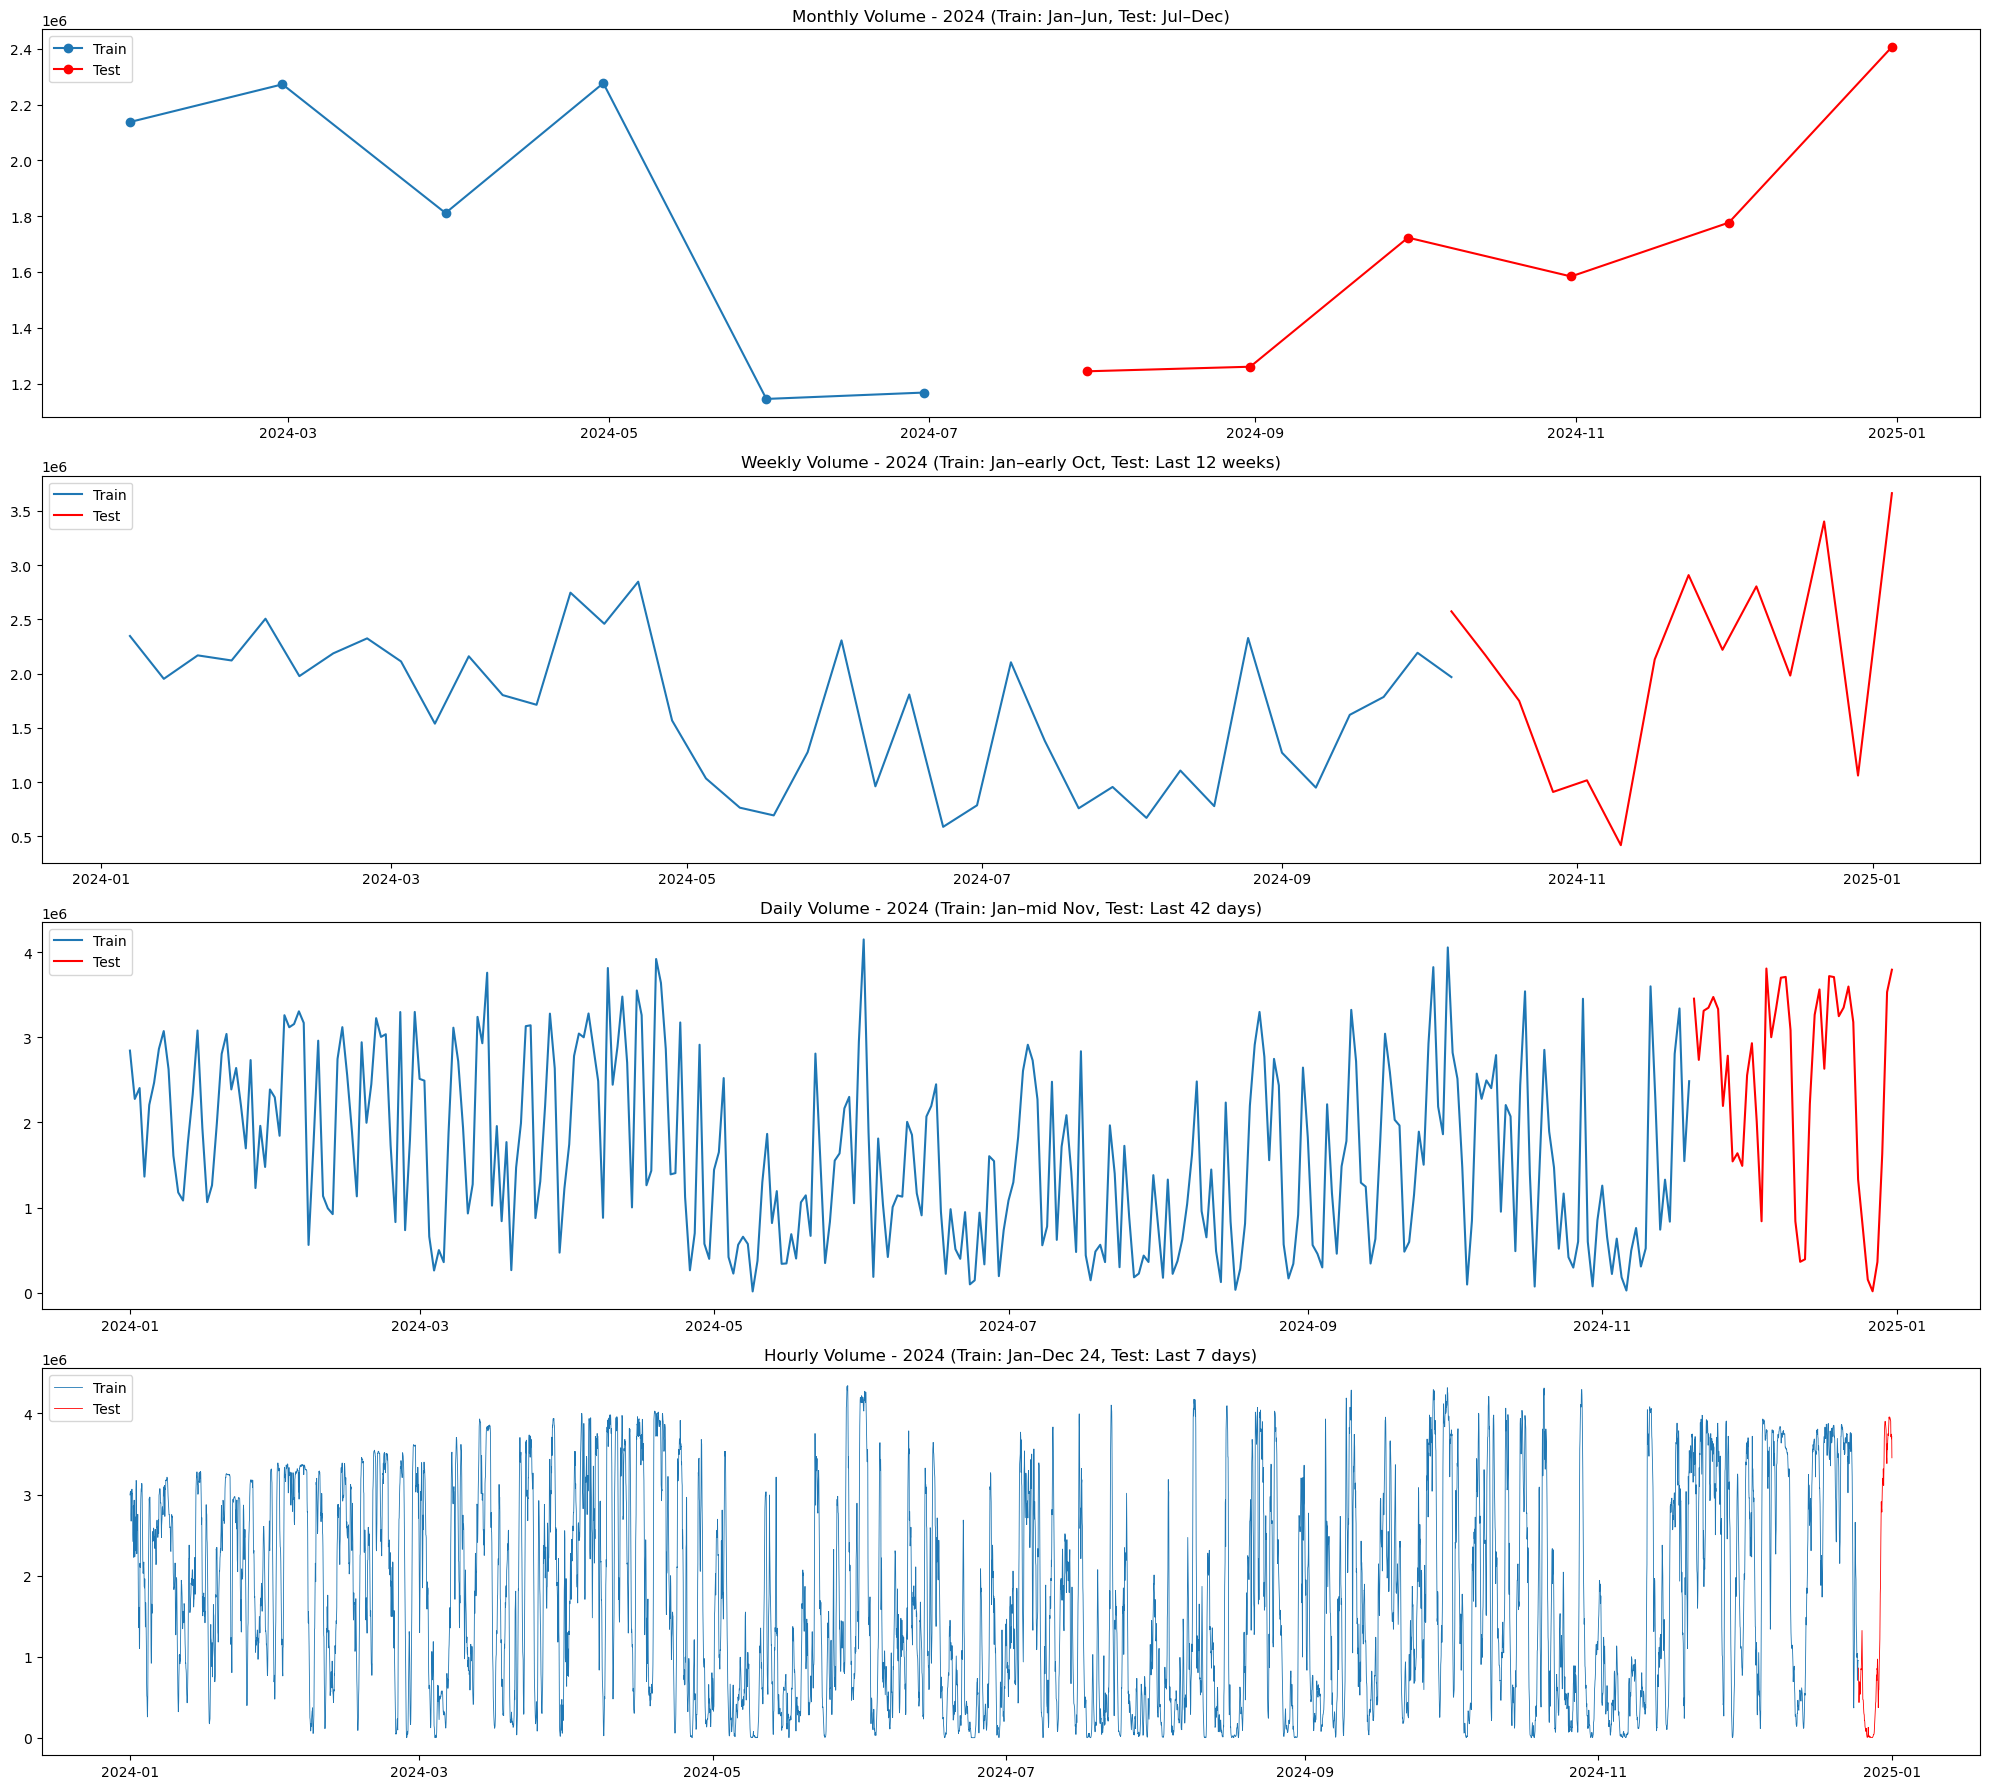

In [341]:
# Define full training base (only 2024)
start_2024 = '2024-01-01'
end_2024 = '2024-12-31'
data_2024 = db_offshore.loc[start_2024:end_2024]

# Define test sets
test_monthly = data_2024.loc['2024-07-01':'2024-12-31']
test_weekly = data_2024.loc['2024-10-06':'2024-12-31']
test_daily = data_2024.loc['2024-11-20':'2024-12-31']
test_hourly = data_2024.loc['2024-12-25':'2024-12-31']

# Corresponding train sets
train_monthly = data_2024.loc[start_2024:'2024-06-30']
train_weekly = data_2024.loc[start_2024:'2024-10-05']
train_daily = data_2024.loc[start_2024:'2024-11-19']
train_hourly = data_2024.loc[start_2024:'2024-12-24']

# Resample train and test
train_monthly_rs = train_monthly['volume'].resample('M').mean()
test_monthly_rs = test_monthly['volume'].resample('M').mean()

train_weekly_rs = train_weekly['volume'].resample('W').mean()
test_weekly_rs = test_weekly['volume'].resample('W').mean()

train_daily_rs = train_daily['volume'].resample('D').mean()
test_daily_rs = test_daily['volume'].resample('D').mean()

# Plotting
fig, axs = plt.subplots(4, 1, figsize=(20, 18), sharex=False)

# Monthly Plot (train + test merged for continuity)
axs[0].plot(train_monthly_rs.index, train_monthly_rs.values, label='Train', marker='o')
axs[0].plot(test_monthly_rs.index, test_monthly_rs.values, label='Test', marker='o', color='red')
axs[0].set_title('Monthly Volume - 2024 (Train: Jan–Jun, Test: Jul–Dec)')
axs[0].legend()

# Weekly
axs[1].plot(train_weekly_rs.index, train_weekly_rs.values, label='Train')
axs[1].plot(test_weekly_rs.index, test_weekly_rs.values, label='Test', color='red')
axs[1].set_title('Weekly Volume - 2024 (Train: Jan–early Oct, Test: Last 12 weeks)')
axs[1].legend()

# Daily
axs[2].plot(train_daily_rs.index, train_daily_rs.values, label='Train')
axs[2].plot(test_daily_rs.index, test_daily_rs.values, label='Test', color='red')
axs[2].set_title('Daily Volume - 2024 (Train: Jan–mid Nov, Test: Last 42 days)')
axs[2].legend()

# Hourly
axs[3].plot(train_hourly.index, train_hourly['volume'], label='Train', linewidth=0.6)
axs[3].plot(test_hourly.index, test_hourly['volume'], label='Test', color='red', linewidth=0.6)
axs[3].set_title('Hourly Volume - 2024 (Train: Jan–Dec 24, Test: Last 7 days)')
axs[3].legend()

plt.tight_layout()
plt.show()

### HW models

In [342]:
# Write the function for Holt-Winters additive model
def fit_and_forecast_hw_additive(train_series, test_series, seasonal_periods):

    # Ensure datetime index
    train_series.index = pd.to_datetime(train_series.index)
    test_series.index = pd.to_datetime(test_series.index)

    # Fit model
    model_fit = ExponentialSmoothing(
        train_series,
        trend='add',
        seasonal='add',
        seasonal_periods=seasonal_periods
    ).fit()

    # Forecast
    forecast = model_fit.forecast(len(test_series))
    #forecast.index = pd.date_range(start=train_series.index[-1] + pd.Timedelta(1, unit='D'), periods=len(test_series), freq=test_series.index.inferred_freq or 'D')

    return model_fit, forecast

#### Offshore data

##### Monthly data

In [343]:
hw_m_model, hw_m_forecast = fit_and_forecast_hw_additive(train_db_m_off['volume'], test_db_m_off['volume'], seasonal_periods=12)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


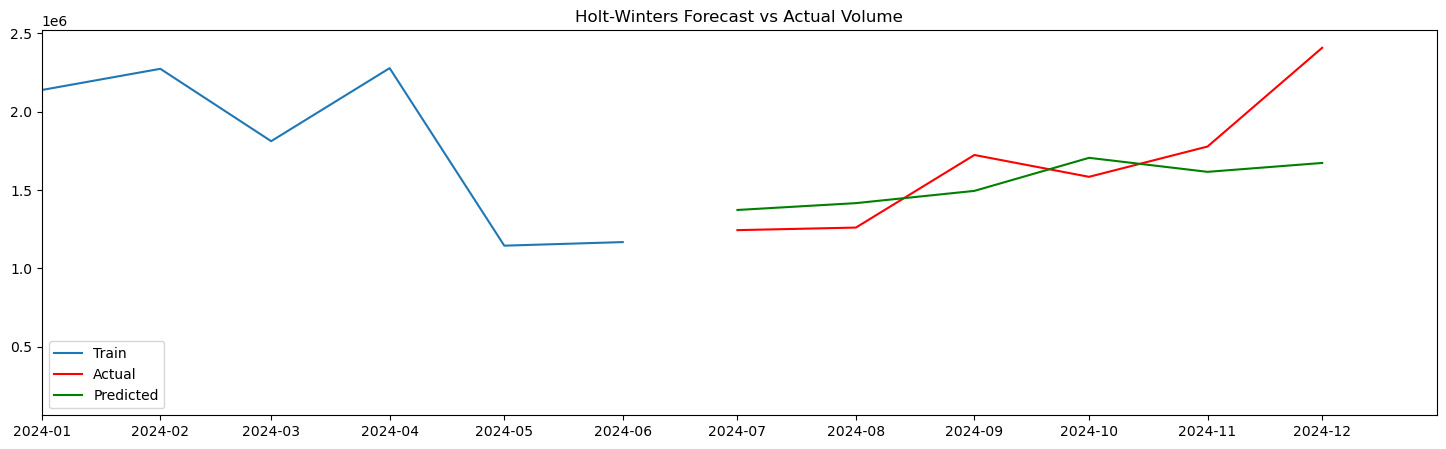

Mean Squared Error (MSE) for Holt-Winters Monthly: 112261328816.29
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 335054.22


In [344]:
plt.figure(figsize=(18, 5))
plt.plot(train_db_m_off['volume'], label="Train")
plt.plot(test_db_m_off['volume'], label="Actual", color='red')
plt.plot(hw_m_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

# MSE
mse_hw_m = mean_squared_error(test_db_m_off['volume'], hw_m_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_m:.2f}")
# RMSE
rmse_hw_m = np.sqrt(mse_hw_m)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_m:.2f}")

##### Final graph for Monthly data

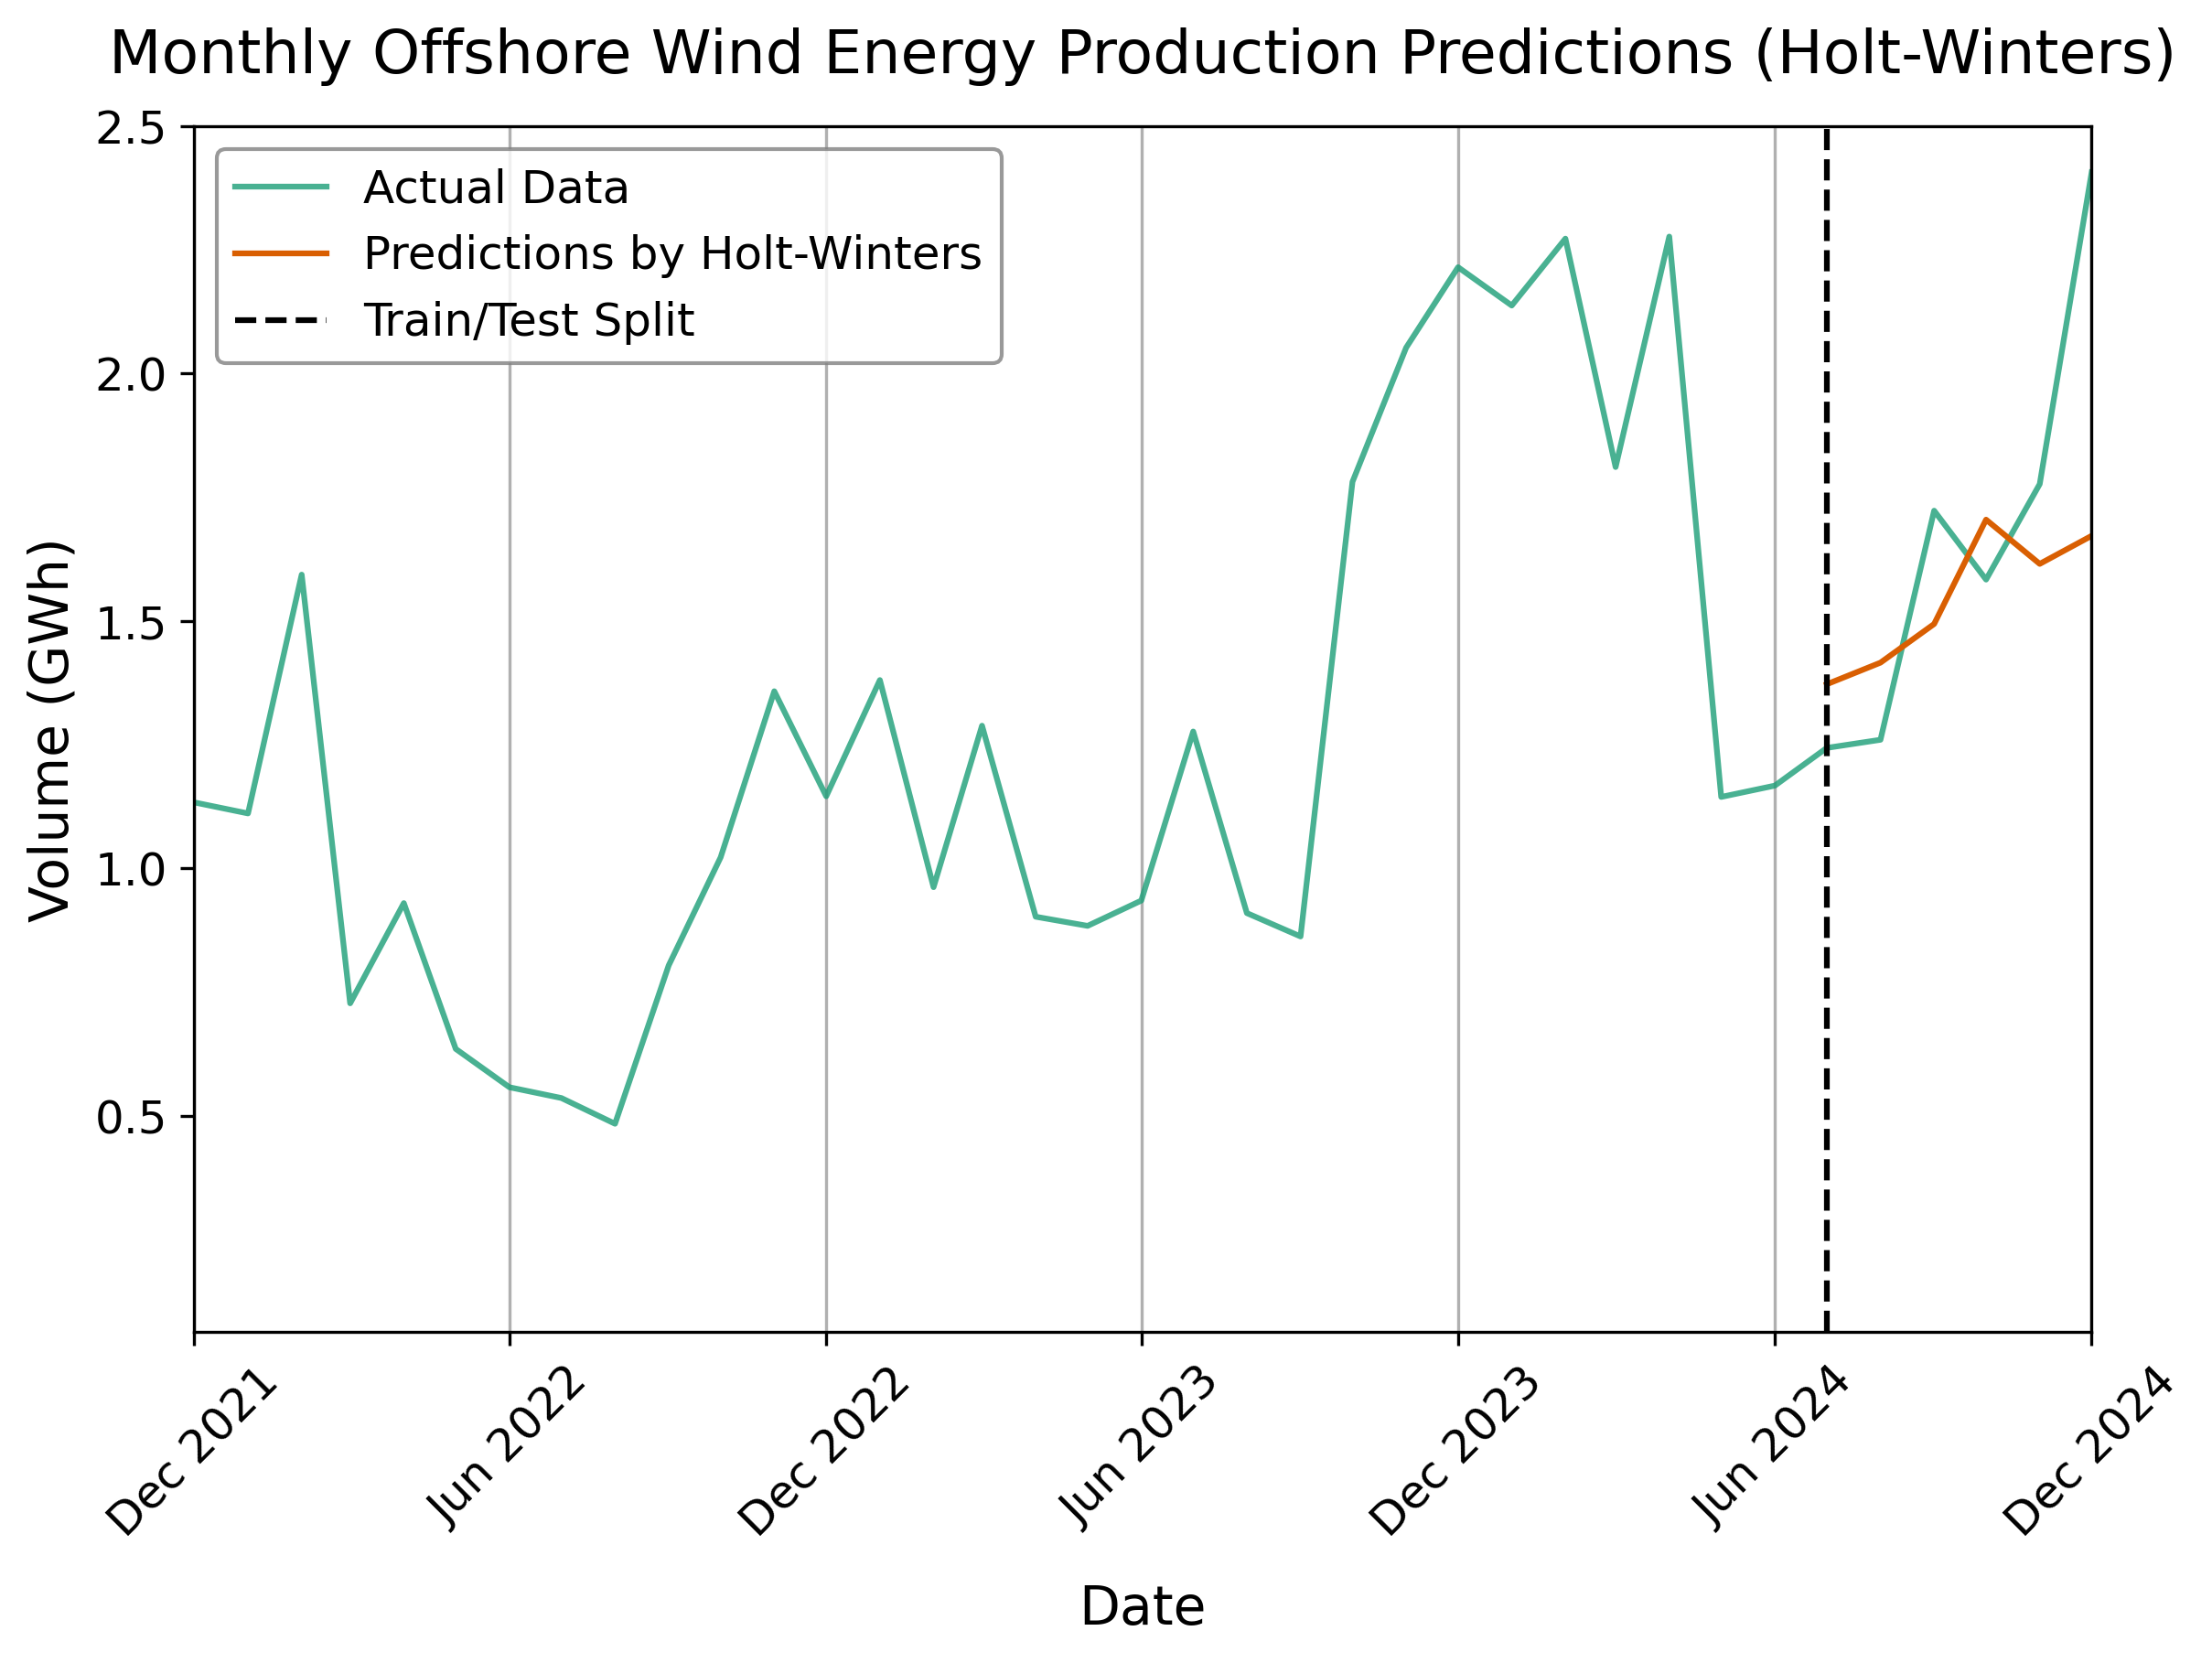

In [345]:
# Function to convert to millions
def millions(x, pos):
    return f'{x * 1e-6:.1f}'

# Create figure with specific size and DPI
fig = plt.figure(figsize=(8, 6), dpi=300)
plt.plot(pd.to_datetime(db_off_monthly.index), db_off_monthly['volume'], label='Actual Data', color='#1b9e77', alpha=0.8)
plt.plot(pd.to_datetime(test_db_m_off.index), hw_m_forecast, label='Predictions by Holt-Winters', color='#d95f02')
split_date = pd.to_datetime(test_db_m_off.index[0], format='%Y-%m')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Monthly Offshore Wind Energy Production Predictions (Holt-Winters)', pad=14, size=16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis='x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2021-12'), pd.to_datetime('2024-12')) 
plt.ylim(top=2_500_000)
plt.tick_params(axis='both', labelsize=12)

# Use tight layout with specified padding - this approximates bbox_inches='tight'
plt.tight_layout(pad=0.5)  # Adjust padding as needed

plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha=0.8)

# Display the figure
plt.show()

##### Weekly data

In [346]:
hw_w_model, hw_w_forecast = fit_and_forecast_hw_additive(train_db_w_off['volume'], test_db_w_off['volume'], seasonal_periods=52)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [347]:
train_db_w_off.tail()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,capacity,volume,percentage
week_number,,,,,,,,
402,239.081691,63.664683,63.812075,10127.731151,73.991497,1.741427e+06,1.741427e+06,0.418814
403,97.460365,62.341553,62.445011,10259.889881,81.887046,1.789653e+06,1.789653e+06,0.430412
404,210.848919,74.193311,74.470805,10034.911210,80.895266,2.010966e+06,2.010966e+06,0.483638
405,116.587399,61.494048,61.633503,10159.435020,81.039116,1.952567e+06,1.952567e+06,0.469593
406,207.180168,66.562358,66.702664,10018.373016,80.727749,2.242372e+06,2.242372e+06,0.539291


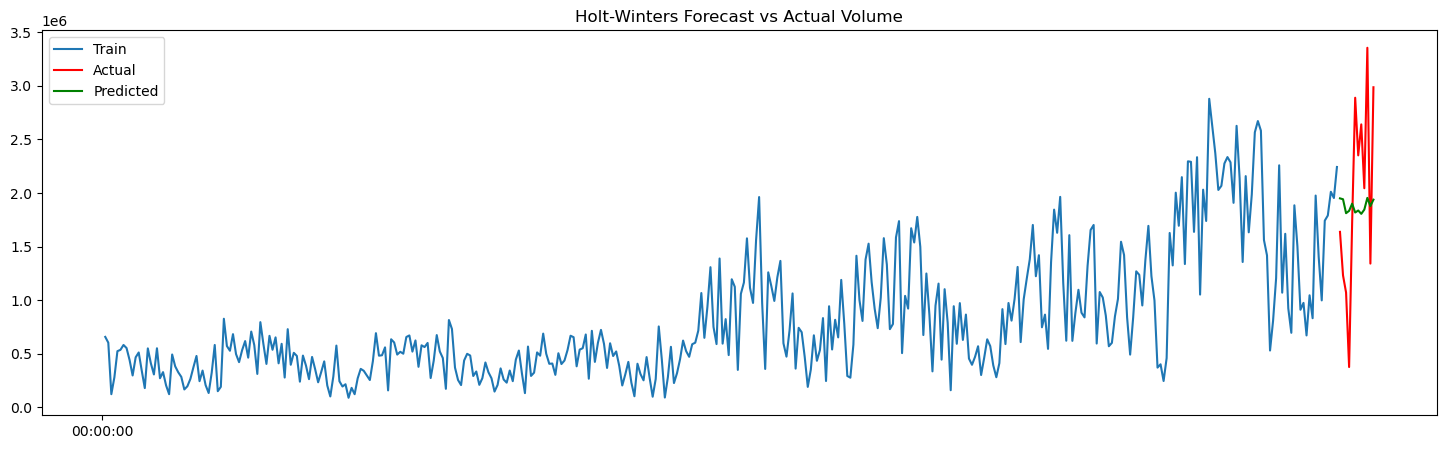

Mean Squared Error (MSE) for Holt-Winters Monthly: 733813733773.28
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 856629.29


In [348]:
plt.figure(figsize=(18,5))
plt.plot(train_db_w_off['volume'], label="Train")
plt.plot(test_db_w_off['volume'], label="Actual", color='red')
plt.plot(hw_w_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.show()

# MSE
mse_hw_w = mean_squared_error(test_db_w_off['volume'], hw_w_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_w:.2f}")
# RMSE
rmse_hw_w = np.sqrt(mse_hw_w)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_w:.2f}")

##### Final graph for Weekly data (DOES NOT WORK)

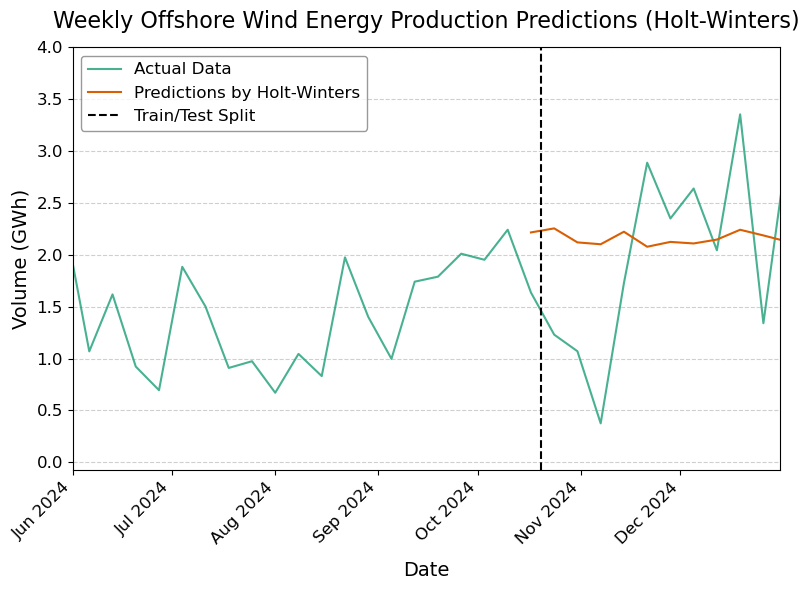

In [397]:
# Define origin date
origin_date = pd.to_datetime('2017-01-01')

# Calculate 407th week date
week_407_date = origin_date + pd.to_timedelta(407, unit='W')

plt.figure(figsize=(8, 6))

# Plot actual data
plt.plot(pd.to_datetime(db_off_weekly.index, origin=origin_date, unit='W'),
         db_off_weekly['volume'], label='Actual Data', color='#1b9e77', alpha=0.8)

# Plot Holt-Winters predictions
plt.plot(pd.to_datetime(test_db_w_off.index, origin=origin_date, unit='W'),
         hw_w_forecast, label='Predictions by Holt-Winters', color='#d95f02')

# Add vertical split line
plt.axvline(x=week_407_date, color='k', linestyle='--', label='Train/Test Split')

# Titles and labels
plt.title('Weekly Offshore Wind Energy Production Predictions (Holt-Winters)', pad=14, size=16)
plt.xlabel('Date', labelpad=10, size=14)
plt.ylabel('Volume (GWh)', size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))  # Assumes you defined 'millions' formatter

# Format x-axis
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')  # Align x-axis labels neatly

# Horizontal grid lines only
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Set time range from June to December 2024
plt.xlim(pd.to_datetime('2024-06-01'), pd.to_datetime('2024-12-31'))
plt.ylim(top=4_000_000)

# Ticks and legend
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha=0.8)

plt.show()

##### Daily data

In [349]:
hw_d_model, hw_d_forecast = fit_and_forecast_hw_additive(train_db_d_off['volume'], test_db_d_off['volume'], seasonal_periods=365)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


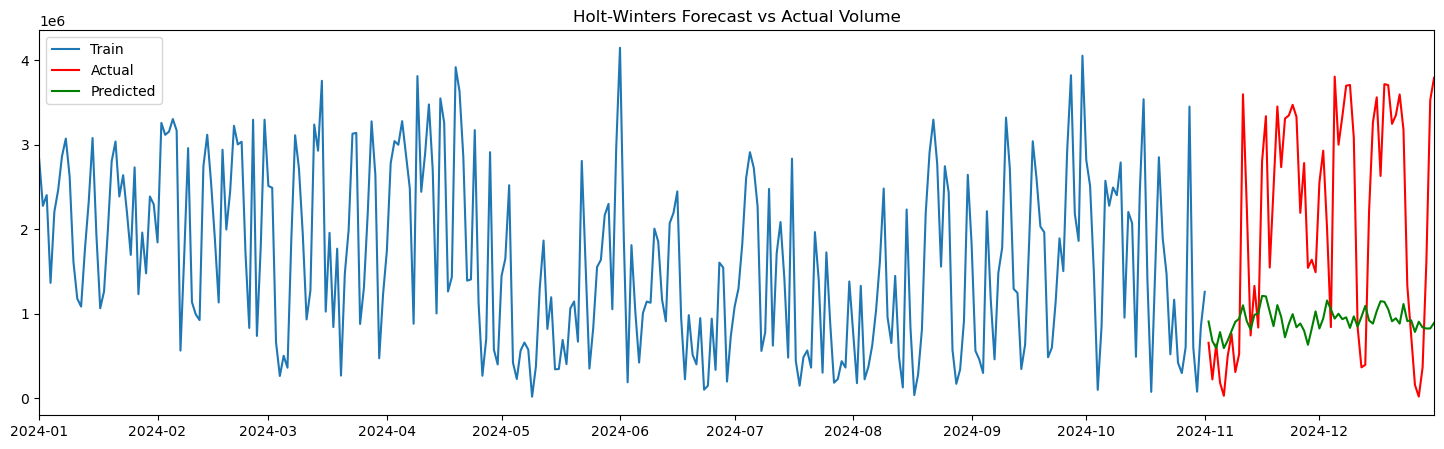

Mean Squared Error (MSE) for Holt-Winters Monthly: 2975400705299.78
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 1724934.99


In [350]:
plt.figure(figsize=(18, 5))
plt.plot(train_db_d_off['volume'], label="Train")
plt.plot(test_db_d_off['volume'], label="Actual", color='red')
plt.plot(hw_d_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

# MSE
mse_hw_d = mean_squared_error(test_db_d_off['volume'], hw_d_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_d:.2f}")
# RMSE
rmse_hw_d = np.sqrt(mse_hw_d)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_d:.2f}")

##### Final graph for Daily data

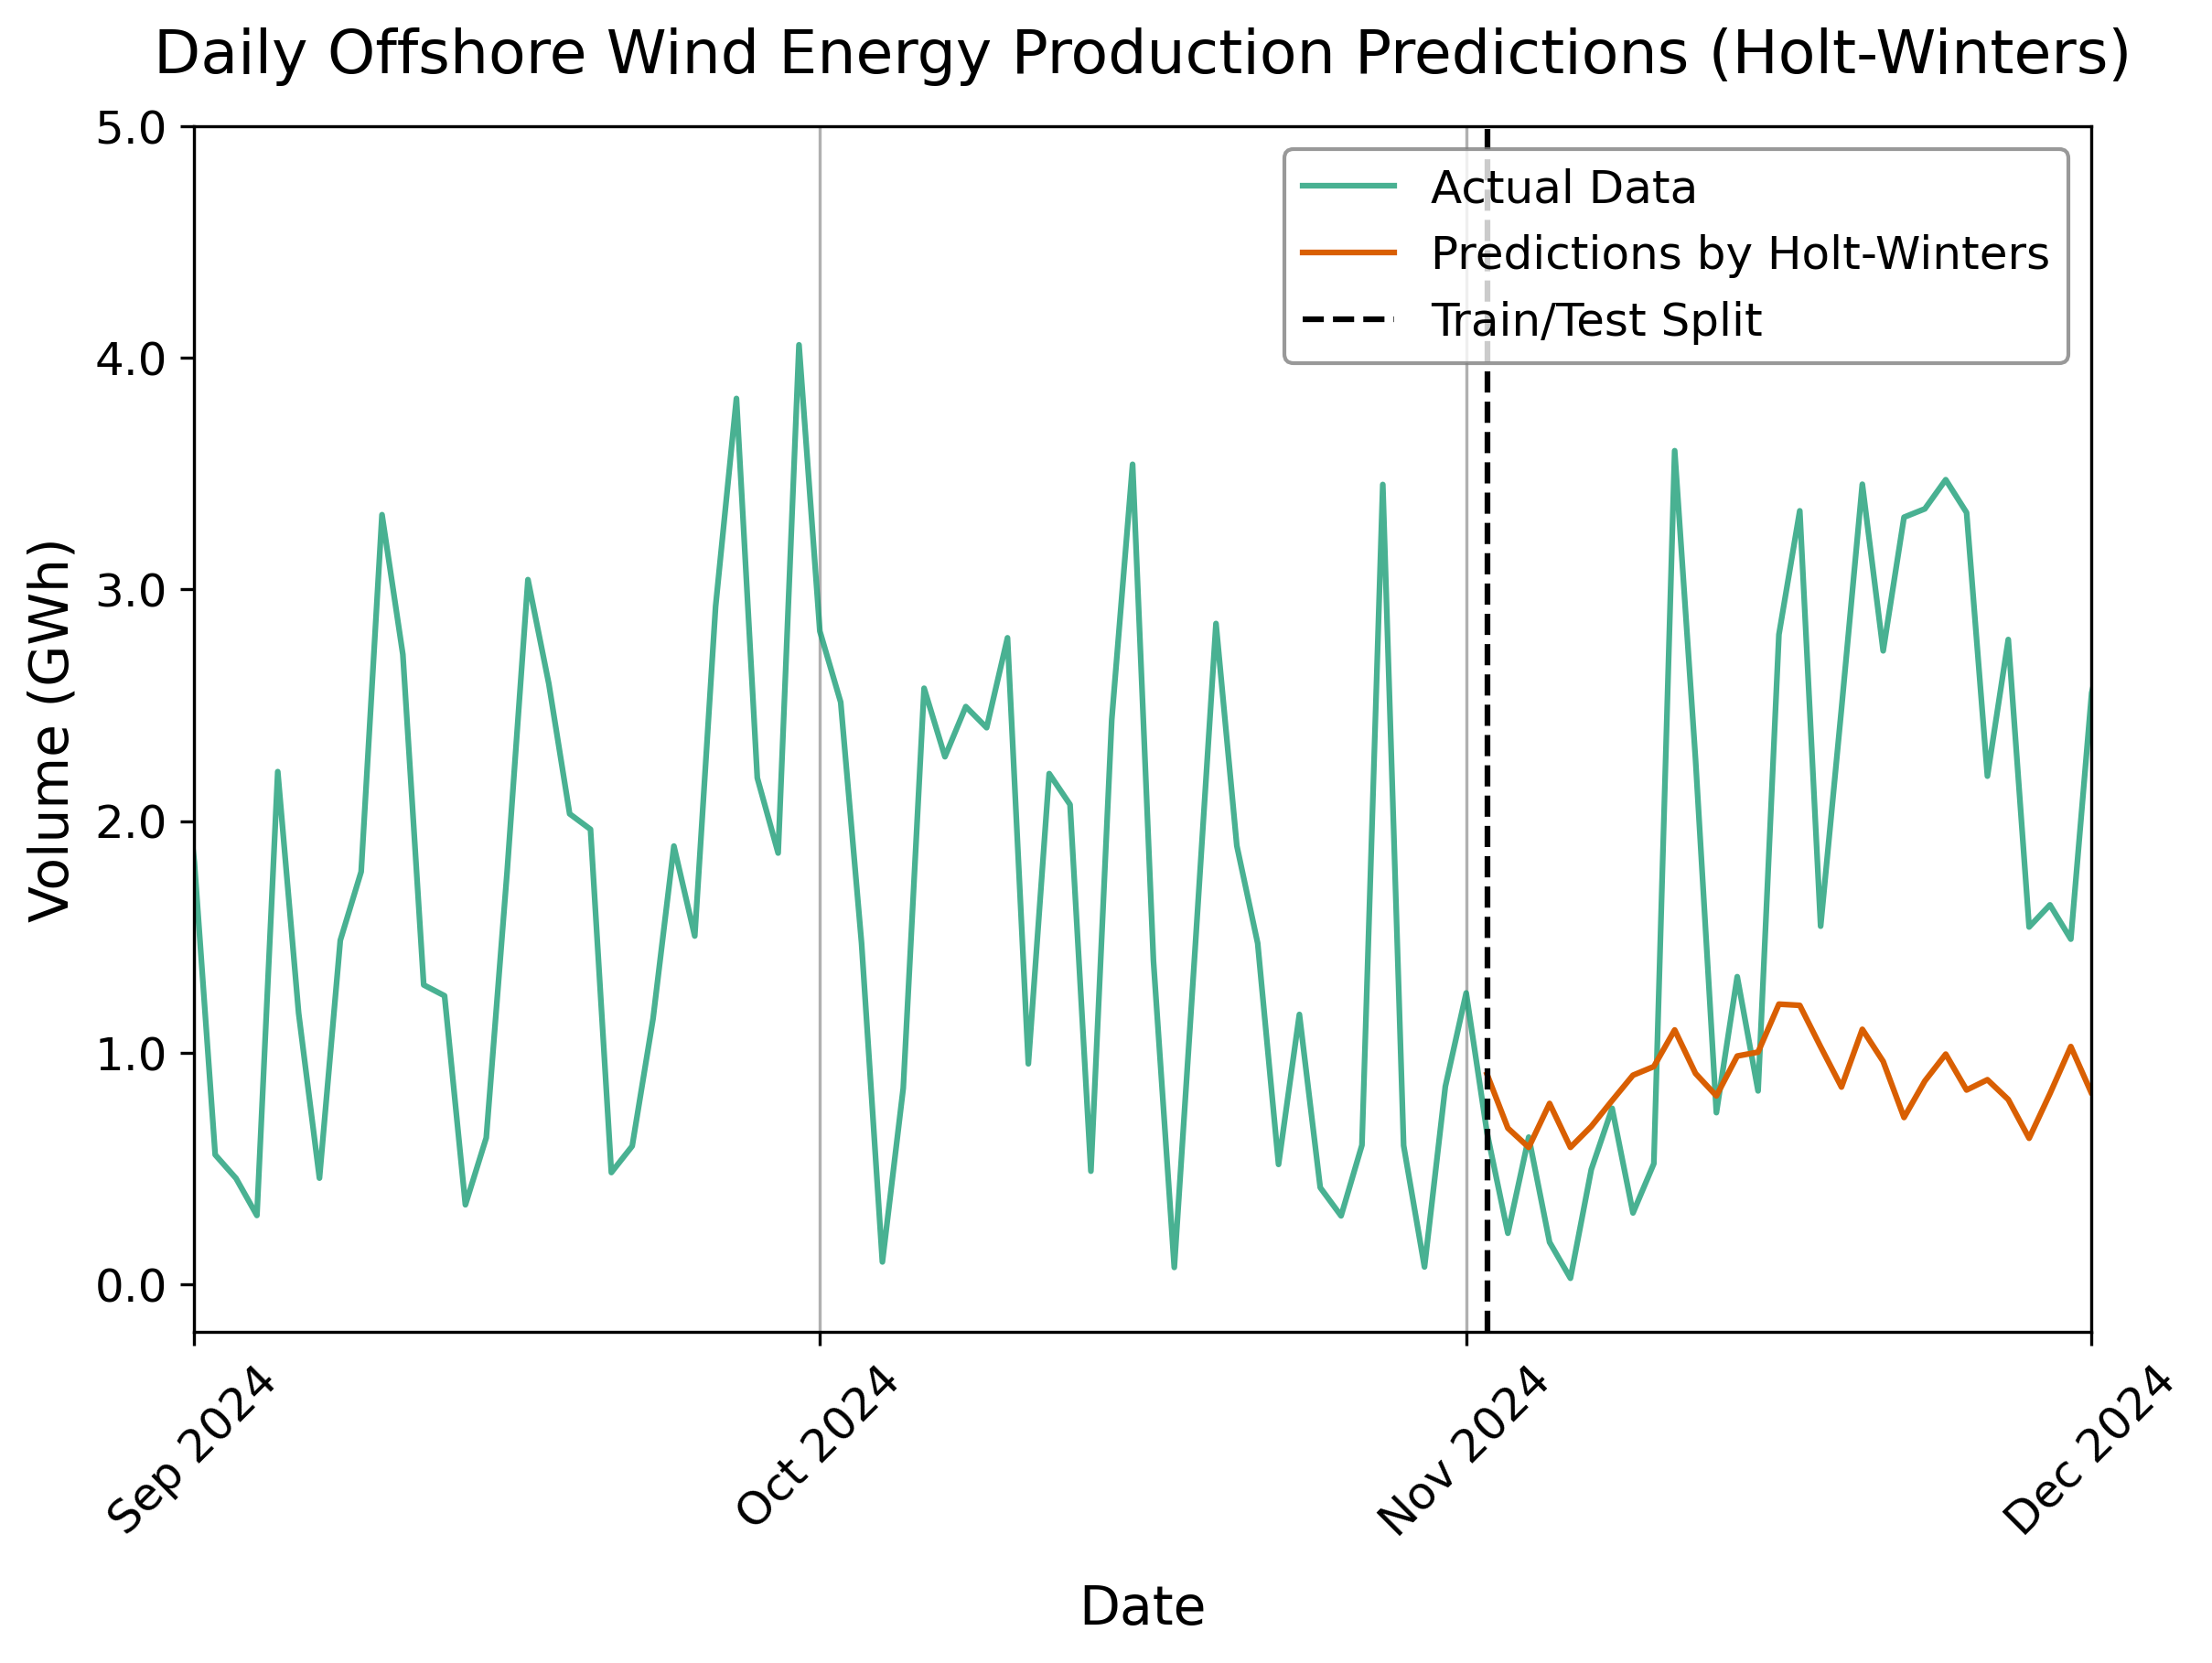

In [351]:
# Create figure with specific size and DPI
fig = plt.figure(figsize=(8, 6), dpi=300)
plt.plot(pd.to_datetime(db_off_daily.index), db_off_daily['volume'], label='Actual Data', color='#1b9e77', alpha=0.8)
plt.plot(pd.to_datetime(test_db_d_off.index), hw_d_forecast, label='Predictions by Holt-Winters', color='#d95f02')
split_date = pd.to_datetime(test_db_d_off.index[0], format='%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Daily Offshore Wind Energy Production Predictions (Holt-Winters)', pad=14, size=16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis='x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-09'), pd.to_datetime('2024-12')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)

# Use tight layout with specified padding - this approximates bbox_inches='tight'
plt.tight_layout(pad=0.5)  # Adjust padding as needed

plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha=0.8)

# Display the figure
plt.show()

##### Hourly data

In [352]:
# Alternative approach
# Assume `train_db_h` contains hourly wind energy production data
series = train_db_h_off['volume']

# Step 1: STL Decomposition
stl = STL(series, period=168)  # Weekly seasonality (24 hours * 7 days)
result = stl.fit()

# Extract components
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Step 2: Apply Holt-Winters to the trend component
hw_model = ExponentialSmoothing(trend.dropna(), trend='add', seasonal=None).fit()

# Step 3: Forecast trend and add seasonal component back
trend_forecast = hw_model.forecast(len(test_db_h_off))
seasonal_forecast = seasonal[-len(test_db_h_off):].values  # Repeat last known seasonality

final_forecast = trend_forecast + seasonal_forecast  # Reconstruct final forecast

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


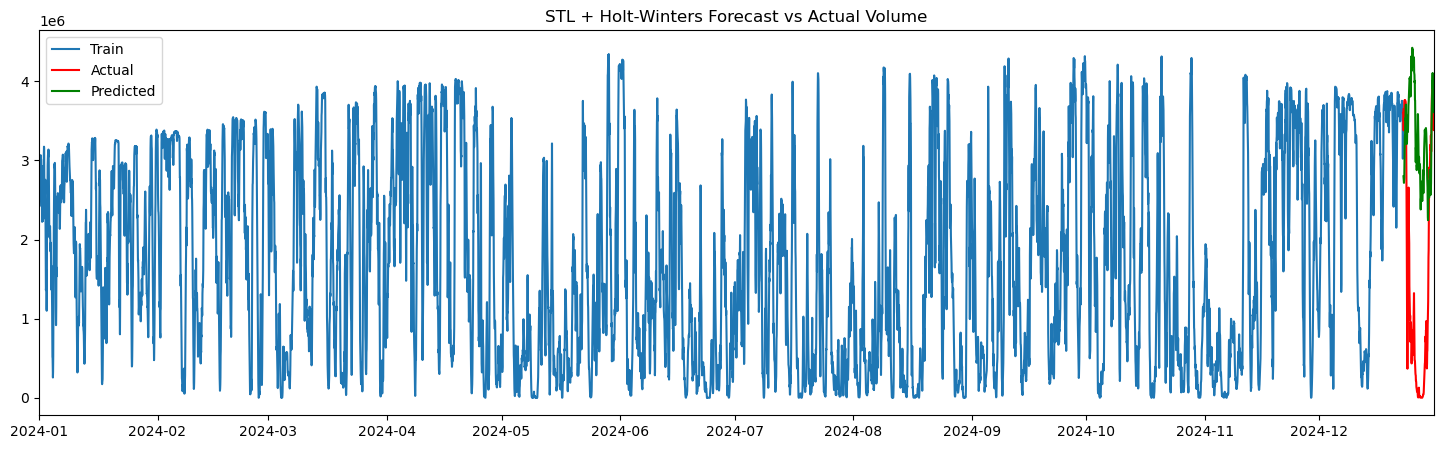

In [353]:
# Plot results
plt.figure(figsize=(18, 5))
plt.plot(train_db_h_off.index, train_db_h_off['volume'], label="Train")
plt.plot(test_db_h_off.index, test_db_h_off['volume'], label="Actual", color='red')
plt.plot(test_db_h_off.index, final_forecast, label="Predicted", color='green')
plt.legend()
plt.title("STL + Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

In [354]:
# MSE
mse_hw_h = mean_squared_error(test_db_h_off['volume'], final_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_h:.2f}")
# RMSE
rmse_hw_h = np.sqrt(mse_hw_h)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_h:.2f}")

Mean Squared Error (MSE) for Holt-Winters Monthly: 5178562341126.91
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 2275645.48


##### Final graph for Hourly data

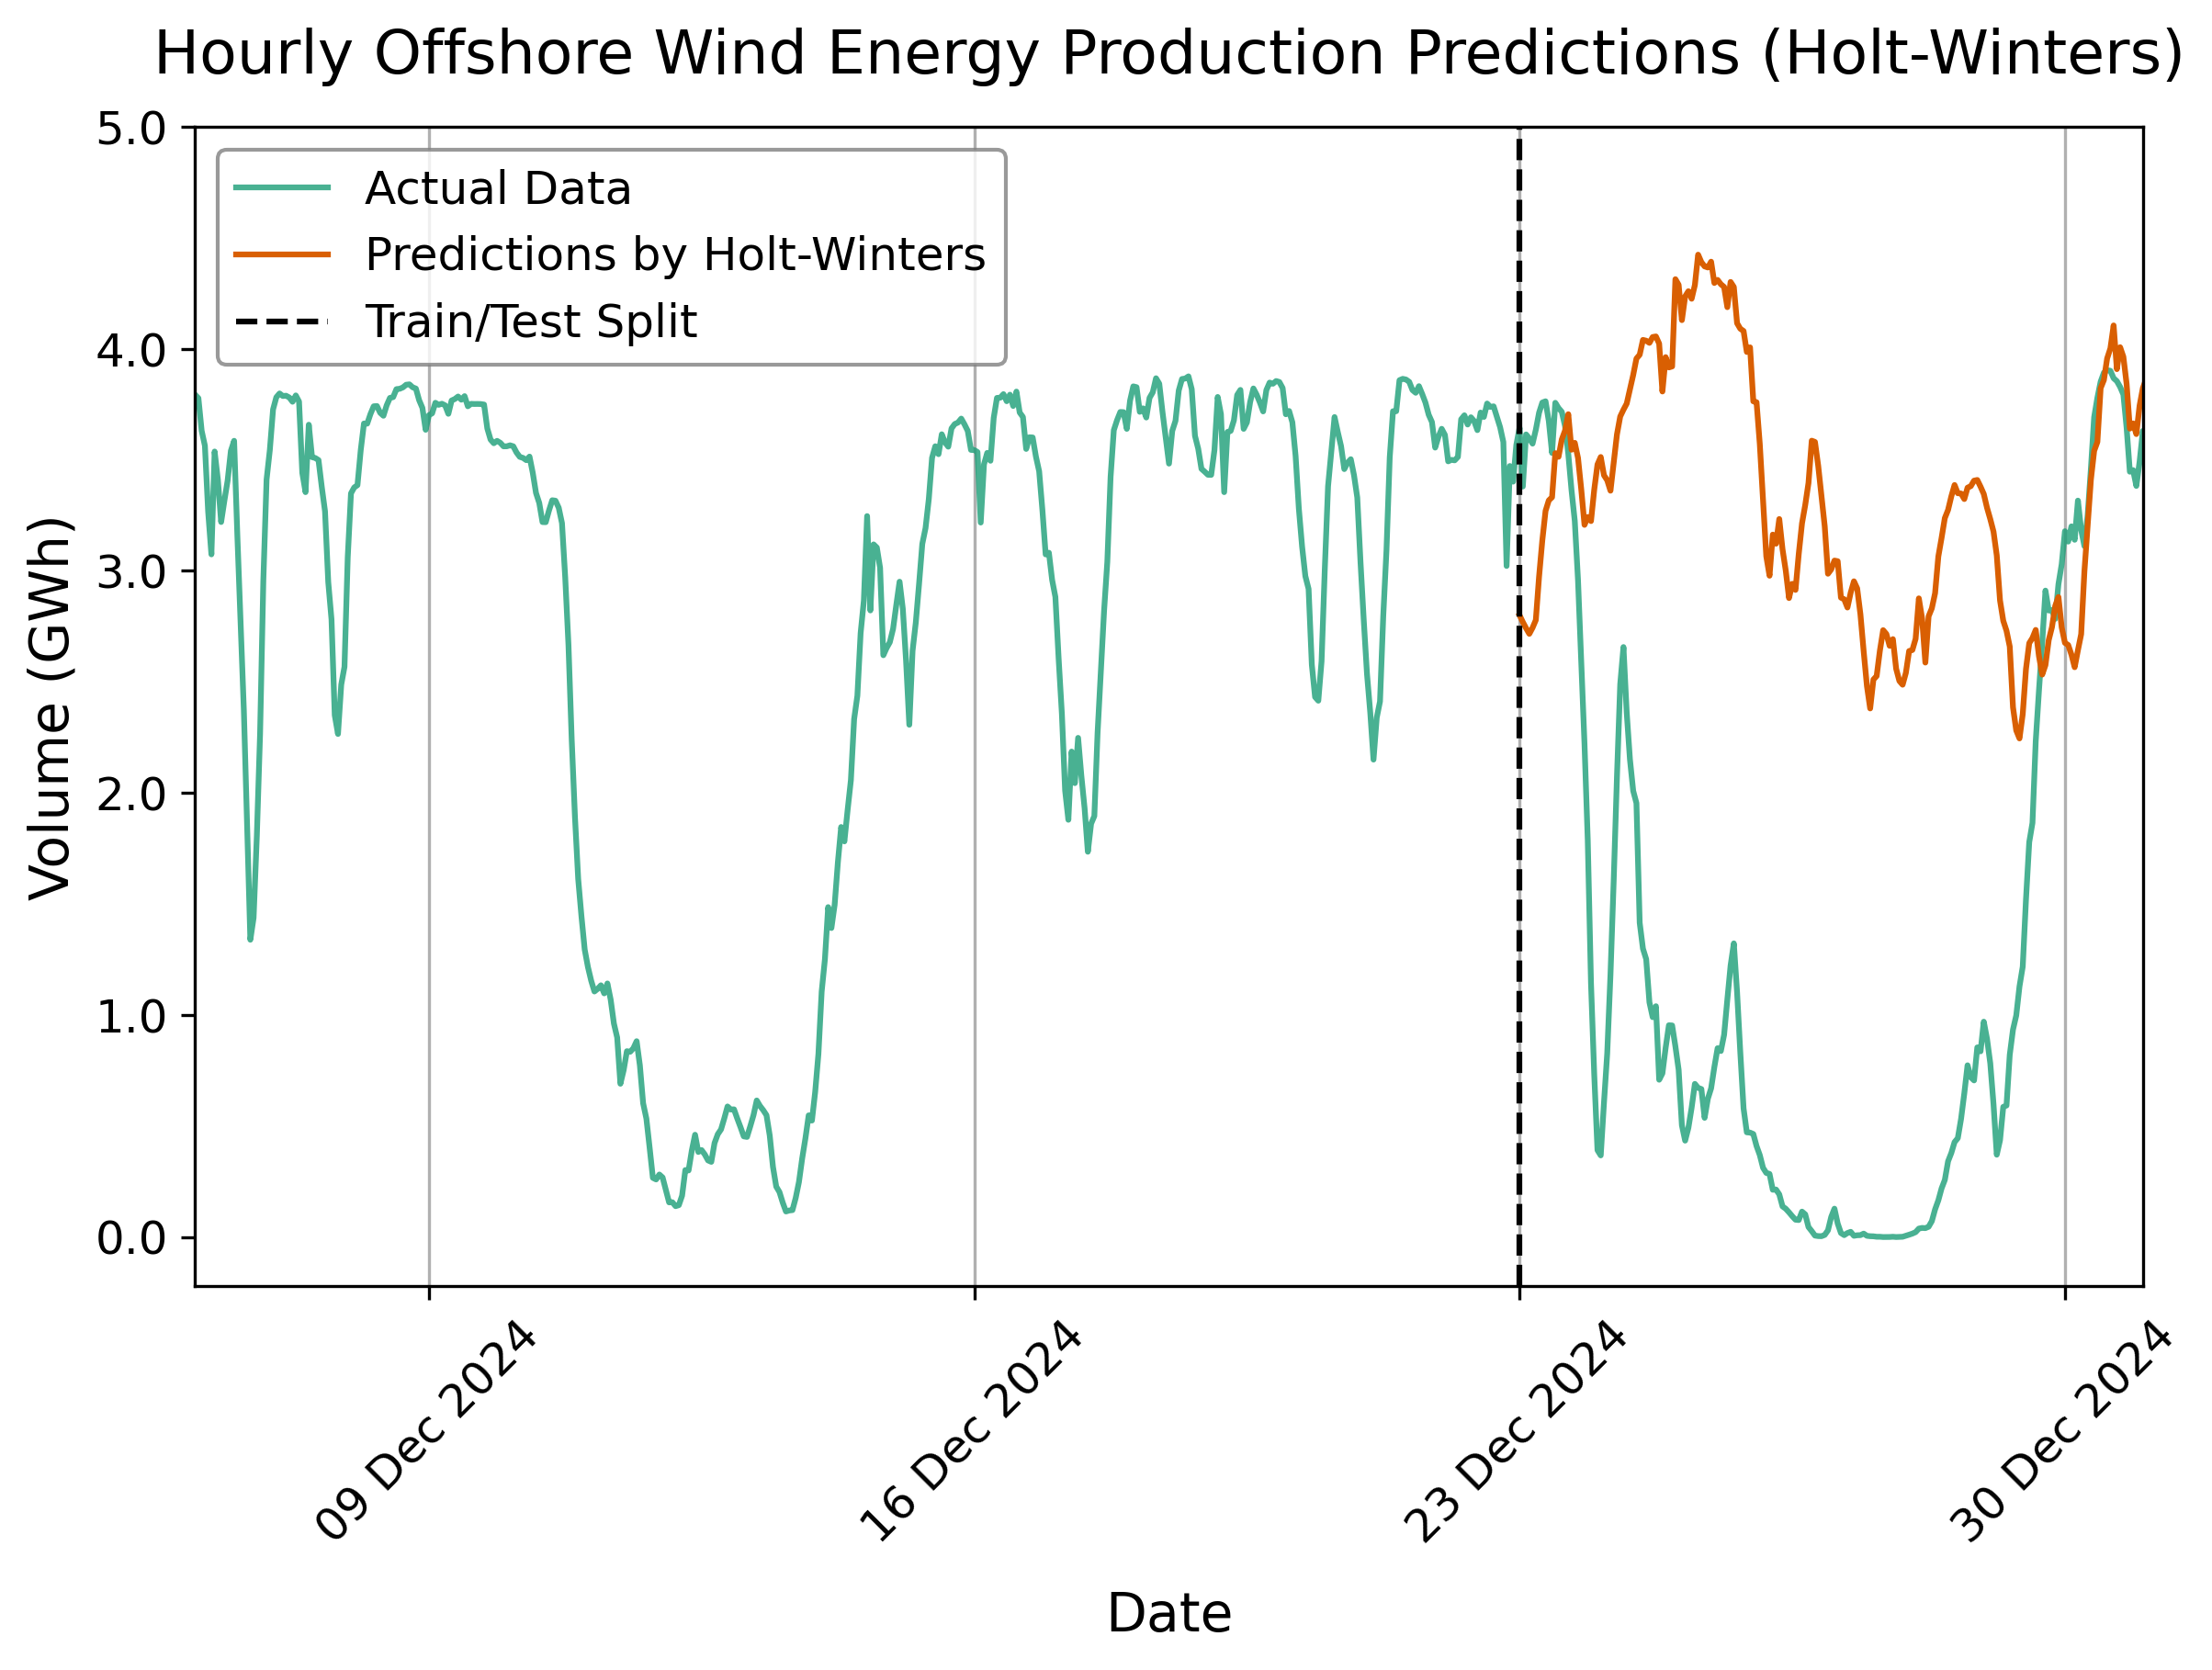

In [355]:
# Create figure with specific size and DPI
fig = plt.figure(figsize=(8, 6), dpi=300)
plt.plot(pd.to_datetime(db_off_hourly.index), db_off_hourly['volume'], label='Actual Data', color='#1b9e77', alpha=0.8)
plt.plot(pd.to_datetime(test_db_h_off.index), final_forecast, label='Predictions by Holt-Winters', color='#d95f02')
split_date = pd.to_datetime(test_db_h_off.index[0], format='%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Hourly Offshore Wind Energy Production Predictions (Holt-Winters)', pad=14, size=16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis='x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xlim(pd.to_datetime('2024-12-06'), pd.to_datetime('2024-12-31')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)

# Use tight layout with specified padding - this approximates bbox_inches='tight'
plt.tight_layout(pad=0.5)  # Adjust padding as needed

plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha=0.8)

# Display the figure
plt.show()

#### ALT TAKE (LOG_VOLUME): Offshore data

##### Daily data

In [356]:
train_db_d_off['log_volume'] = np.log(train_db_d_off['volume'])
test_db_d_off['log_volume'] = np.log(test_db_d_off['volume'])

/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_92598/1634191168.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_db_d_off['log_volume'] = np.log(train_db_d_off['volume'])
/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_92598/1634191168.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_db_d_off['log_volume'] = np.log(test_db_d_off['volume'])


In [357]:
hw_d_model_log, hw_d_forecast_log = fit_and_forecast_hw_additive(train_db_d_off['log_volume'], 
                                                                 test_db_d_off['log_volume'], 
                                                                 seasonal_periods=365)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


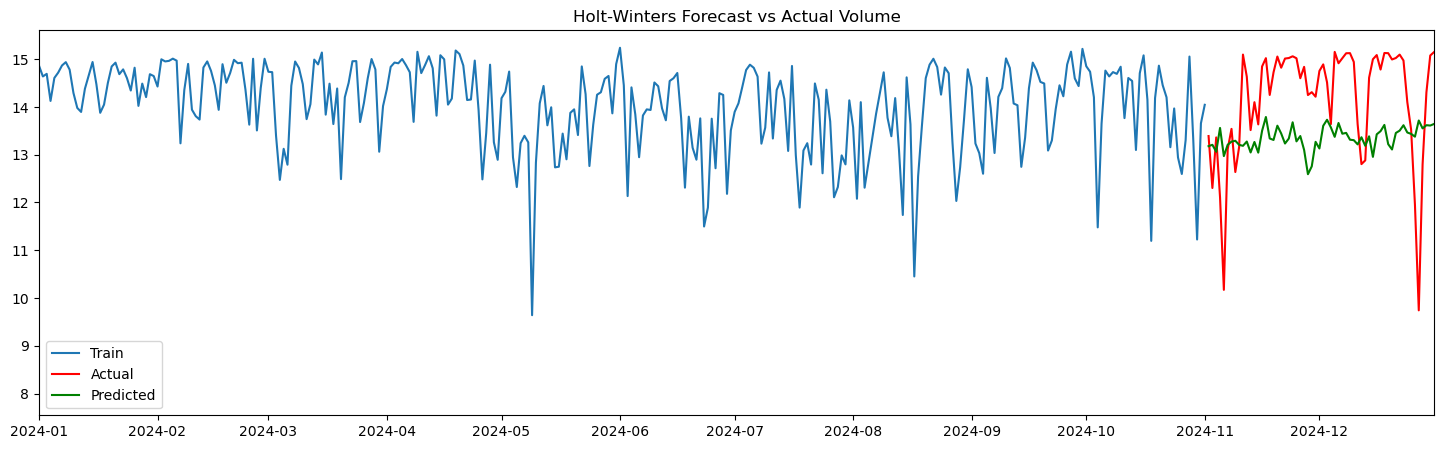

Mean Squared Error (MSE) for Holt-Winters Monthly: 2.02
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 1.42


In [358]:
plt.figure(figsize=(18,5))
plt.plot(train_db_d_off['log_volume'], label="Train")
plt.plot(test_db_d_off['log_volume'], label="Actual", color='red')
plt.plot(hw_d_forecast_log, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

# MSE
mse_hw_d_log = mean_squared_error(test_db_d_off['log_volume'], hw_d_forecast_log)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_d_log:.2f}")
# RMSE
rmse_hw_d_log = np.sqrt(mse_hw_d_log)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_d_log:.2f}")

#print(f"RMSE (back-transformed): {rmse:.2f}")

In [359]:
y_pred = np.exp(hw_d_forecast_log)
y_true_transformed = np.exp(test_db_d_off['log_volume'])  # Should match y_true

# 4. Compare in original scale
mse = mean_squared_error(y_true_transformed, y_pred)
rmse = np.sqrt(mse)

print(f"MSE (back-transformed): {mse:.2f}")
print(f"RMSE (back-transformed): {rmse:.2f}")

MSE (back-transformed): 3739079396534.02
RMSE (back-transformed): 1933669.93


#### Onshore data

##### Monthly data

In [360]:
hw_m_model, hw_m_forecast = fit_and_forecast_hw_additive(train_db_m_on['volume'], test_db_m_on['volume'], seasonal_periods=12)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


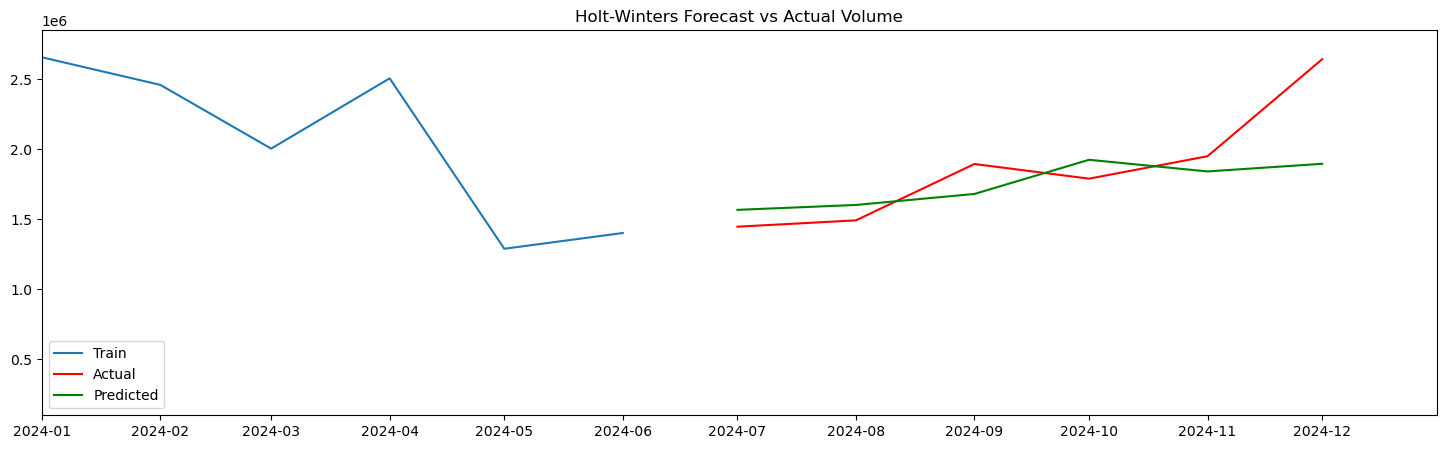

Mean Squared Error (MSE) for Holt-Winters Monthly: 109894203245.41
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 331502.95


In [361]:
plt.figure(figsize=(18, 5))
plt.plot(train_db_m_on['volume'], label="Train")
plt.plot(test_db_m_on['volume'], label="Actual", color='red')
plt.plot(hw_m_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

# MSE
mse_hw_m = mean_squared_error(test_db_m_on['volume'], hw_m_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_m:.2f}")
# RMSE
rmse_hw_m = np.sqrt(mse_hw_m)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_m:.2f}")

##### Final graph for Monthly data

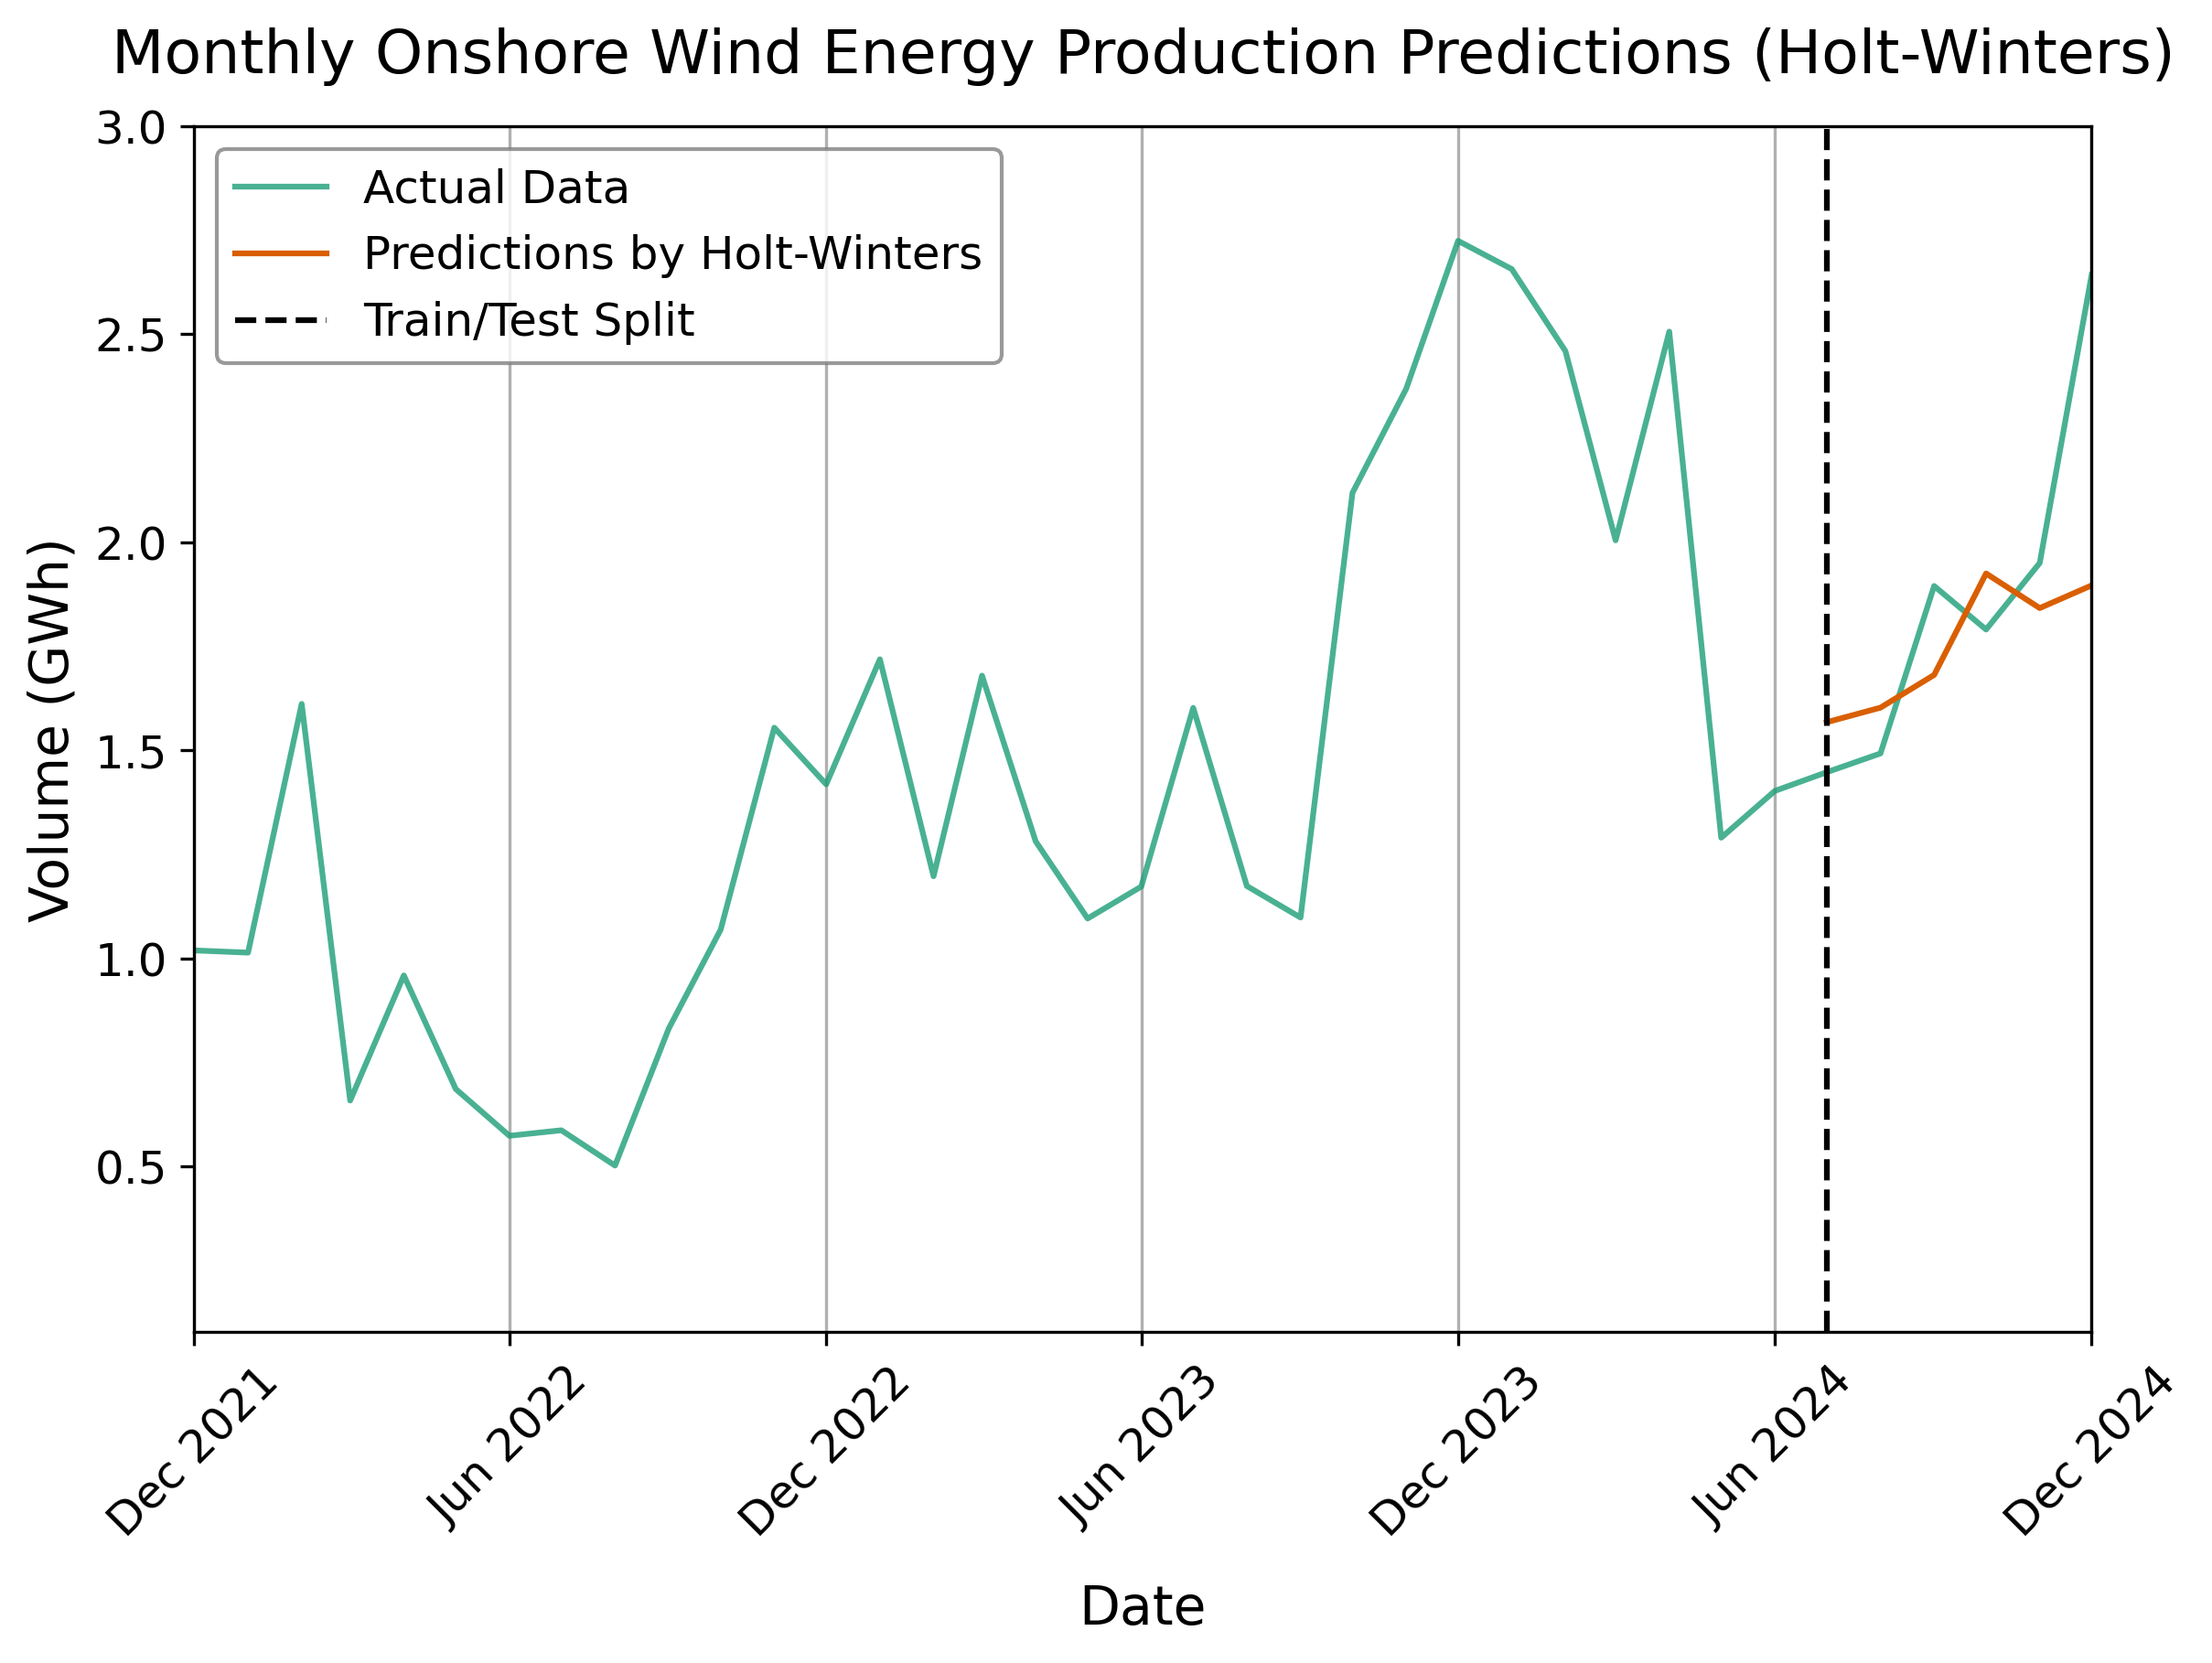

In [362]:
# Create figure with specific size and DPI
fig = plt.figure(figsize=(8, 6), dpi=300)
plt.plot(pd.to_datetime(db_on_monthly.index), db_on_monthly['volume'], label='Actual Data', color='#1b9e77', alpha=0.8)
plt.plot(pd.to_datetime(test_db_m_on.index), hw_m_forecast, label='Predictions by Holt-Winters', color='#d95f02')
split_date = pd.to_datetime(test_db_m_on.index[0], format='%Y-%m')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Monthly Onshore Wind Energy Production Predictions (Holt-Winters)', pad=14, size=16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis='x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2021-12'), pd.to_datetime('2024-12')) 
plt.ylim(top=3_000_000)
plt.tick_params(axis='both', labelsize=12)

# Use tight layout with specified padding - this approximates bbox_inches='tight'
plt.tight_layout(pad=0.5)  # Adjust padding as needed

plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha=0.8)

# Display the figure
plt.show()

##### Weekly data

In [363]:
hw_w_model, hw_w_forecast = fit_and_forecast_hw_additive(train_db_w_on['volume'], test_db_w_on['volume'], seasonal_periods=52)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


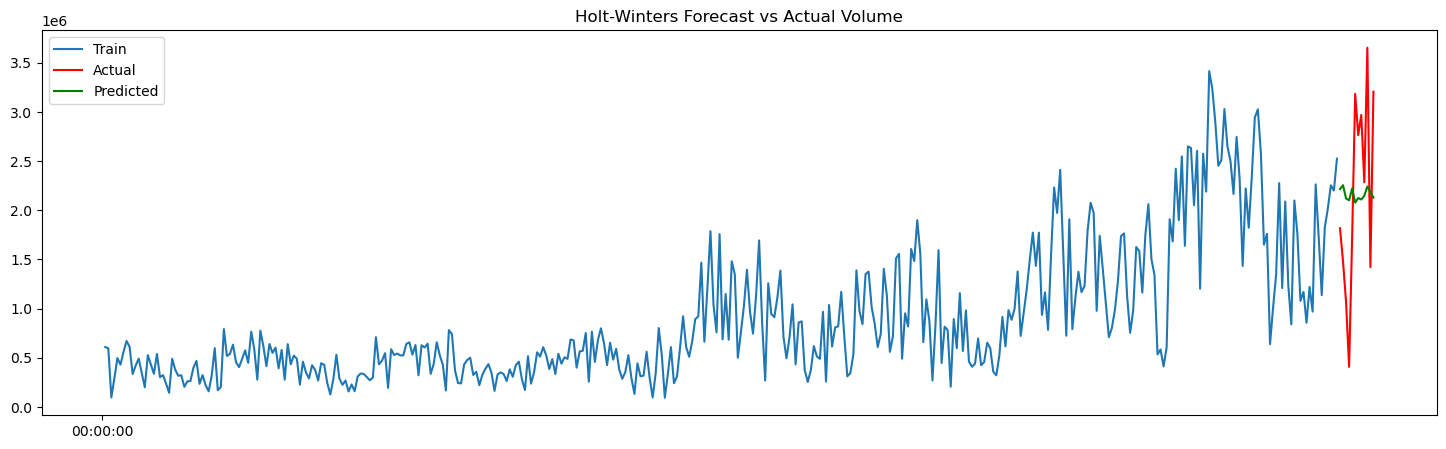

Mean Squared Error (MSE) for Holt-Winters Monthly: 926424651806.57
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 962509.56


In [364]:
plt.figure(figsize=(18,5))
plt.plot(train_db_w_on['volume'], label="Train")
plt.plot(test_db_w_on['volume'], label="Actual", color='red')
plt.plot(hw_w_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.show()

# MSE
mse_hw_w = mean_squared_error(test_db_w_on['volume'], hw_w_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_w:.2f}")
# RMSE
rmse_hw_w = np.sqrt(mse_hw_w)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_w:.2f}")

##### Final graph for Weekly data

In [365]:
# Create figure with specific size and DPI
# RETURN LATER

##### Daily data

In [366]:
hw_d_model, hw_d_forecast = fit_and_forecast_hw_additive(train_db_d_on['volume'], test_db_d_on['volume'], seasonal_periods=365)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


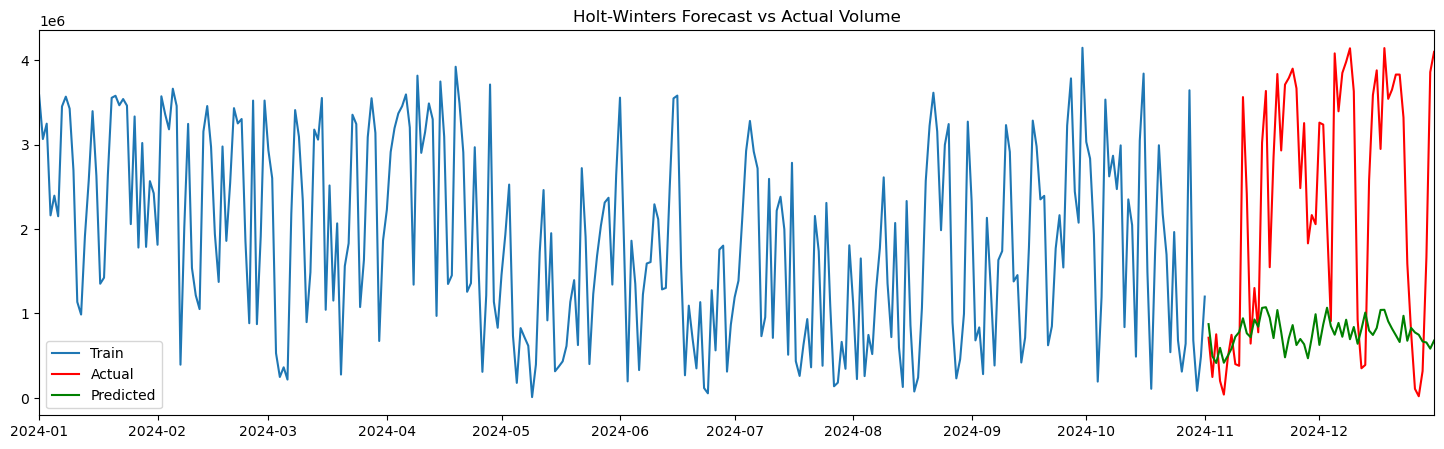

Mean Squared Error (MSE) for Holt-Winters Monthly: 4352200174597.40
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 2086192.75


In [367]:
plt.figure(figsize=(18, 5))
plt.plot(train_db_d_on['volume'], label="Train")
plt.plot(test_db_d_on['volume'], label="Actual", color='red')
plt.plot(hw_d_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

# MSE
mse_hw_d = mean_squared_error(test_db_d_on['volume'], hw_d_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_d:.2f}")
# RMSE
rmse_hw_d = np.sqrt(mse_hw_d)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_d:.2f}")

##### Final graph for Daily data

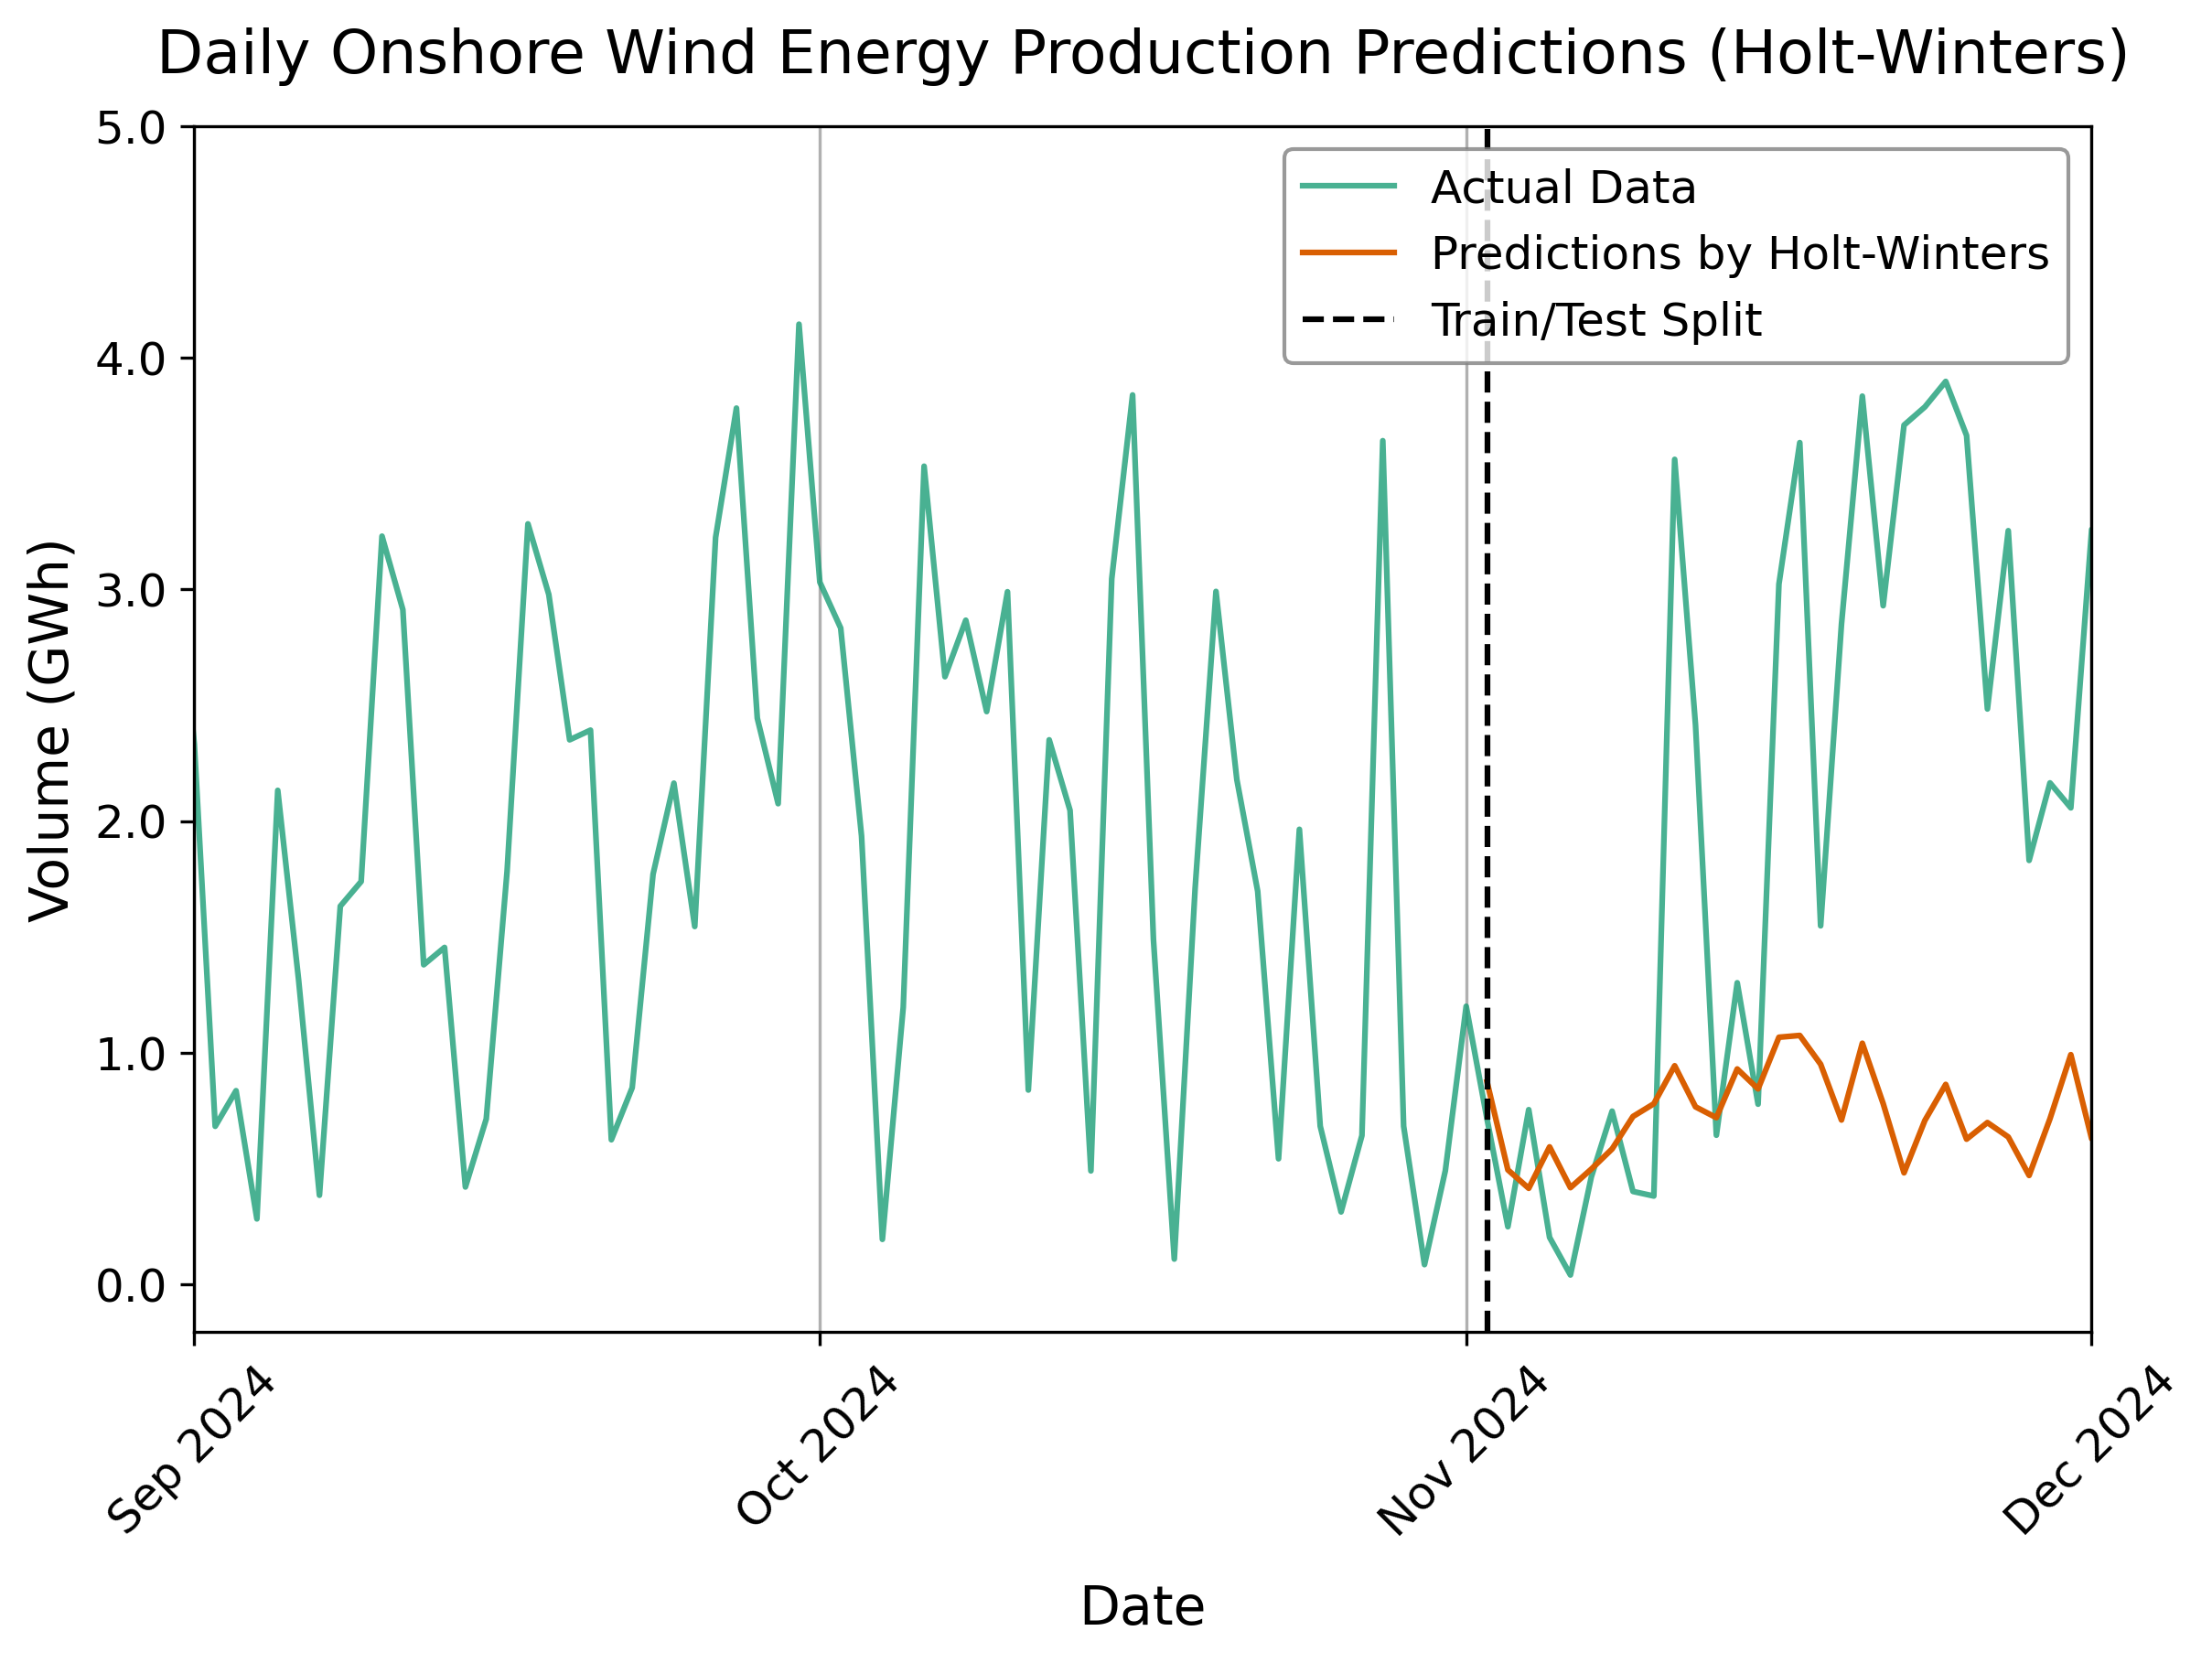

In [368]:
# Create figure with specific size and DPI
fig = plt.figure(figsize=(8, 6), dpi=300)
plt.plot(pd.to_datetime(db_on_daily.index), db_on_daily['volume'], label='Actual Data', color='#1b9e77', alpha=0.8)
plt.plot(pd.to_datetime(test_db_d_on.index), hw_d_forecast, label='Predictions by Holt-Winters', color='#d95f02')
split_date = pd.to_datetime(test_db_d_on.index[0], format='%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Daily Onshore Wind Energy Production Predictions (Holt-Winters)', pad=14, size=16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis='x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-09'), pd.to_datetime('2024-12')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)

# Use tight layout with specified padding - this approximates bbox_inches='tight'
plt.tight_layout(pad=0.5)  # Adjust padding as needed

plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha=0.8)

# Display the figure
plt.show()

##### Hourly data

In [369]:
# Alternative approach
# Assume `train_db_h` contains hourly wind energy production data
series = train_db_h_on['volume']

# Step 1: STL Decomposition
stl = STL(series, period=168)  # Weekly seasonality (24 hours * 7 days)
result = stl.fit()

# Extract components
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Step 2: Apply Holt-Winters to the trend component
hw_model = ExponentialSmoothing(trend.dropna(), trend='add', seasonal=None).fit()

# Step 3: Forecast trend and add seasonal component back
trend_forecast = hw_model.forecast(len(test_db_h_on))
seasonal_forecast = seasonal[-len(test_db_h_on):].values  # Repeat last known seasonality

final_forecast = trend_forecast + seasonal_forecast  # Reconstruct final forecast

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


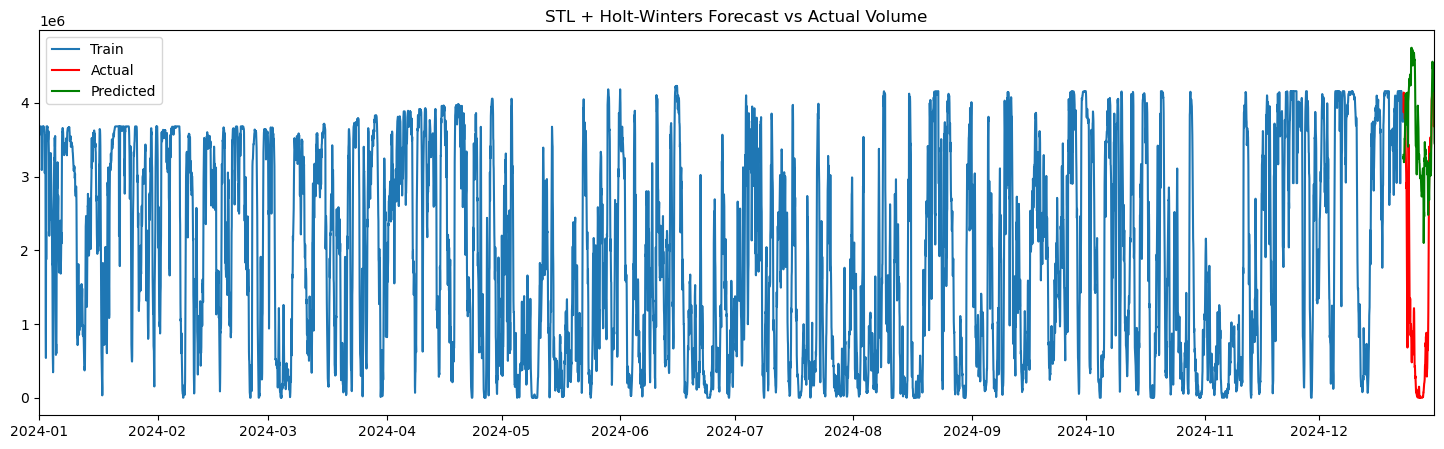

In [370]:
# Plot results
plt.figure(figsize=(18, 5))
plt.plot(train_db_h_on.index, train_db_h_on['volume'], label="Train")
plt.plot(test_db_h_on.index, test_db_h_on['volume'], label="Actual", color='red')
plt.plot(test_db_h_on.index, final_forecast, label="Predicted", color='green')
plt.legend()
plt.title("STL + Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

In [371]:
# MSE
mse_hw_h = mean_squared_error(test_db_h_on['volume'], final_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_h:.2f}")
# RMSE
rmse_hw_h = np.sqrt(mse_hw_h)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_h:.2f}")

Mean Squared Error (MSE) for Holt-Winters Monthly: 6153620569454.77
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 2480649.22


##### Final graph for Hourly data

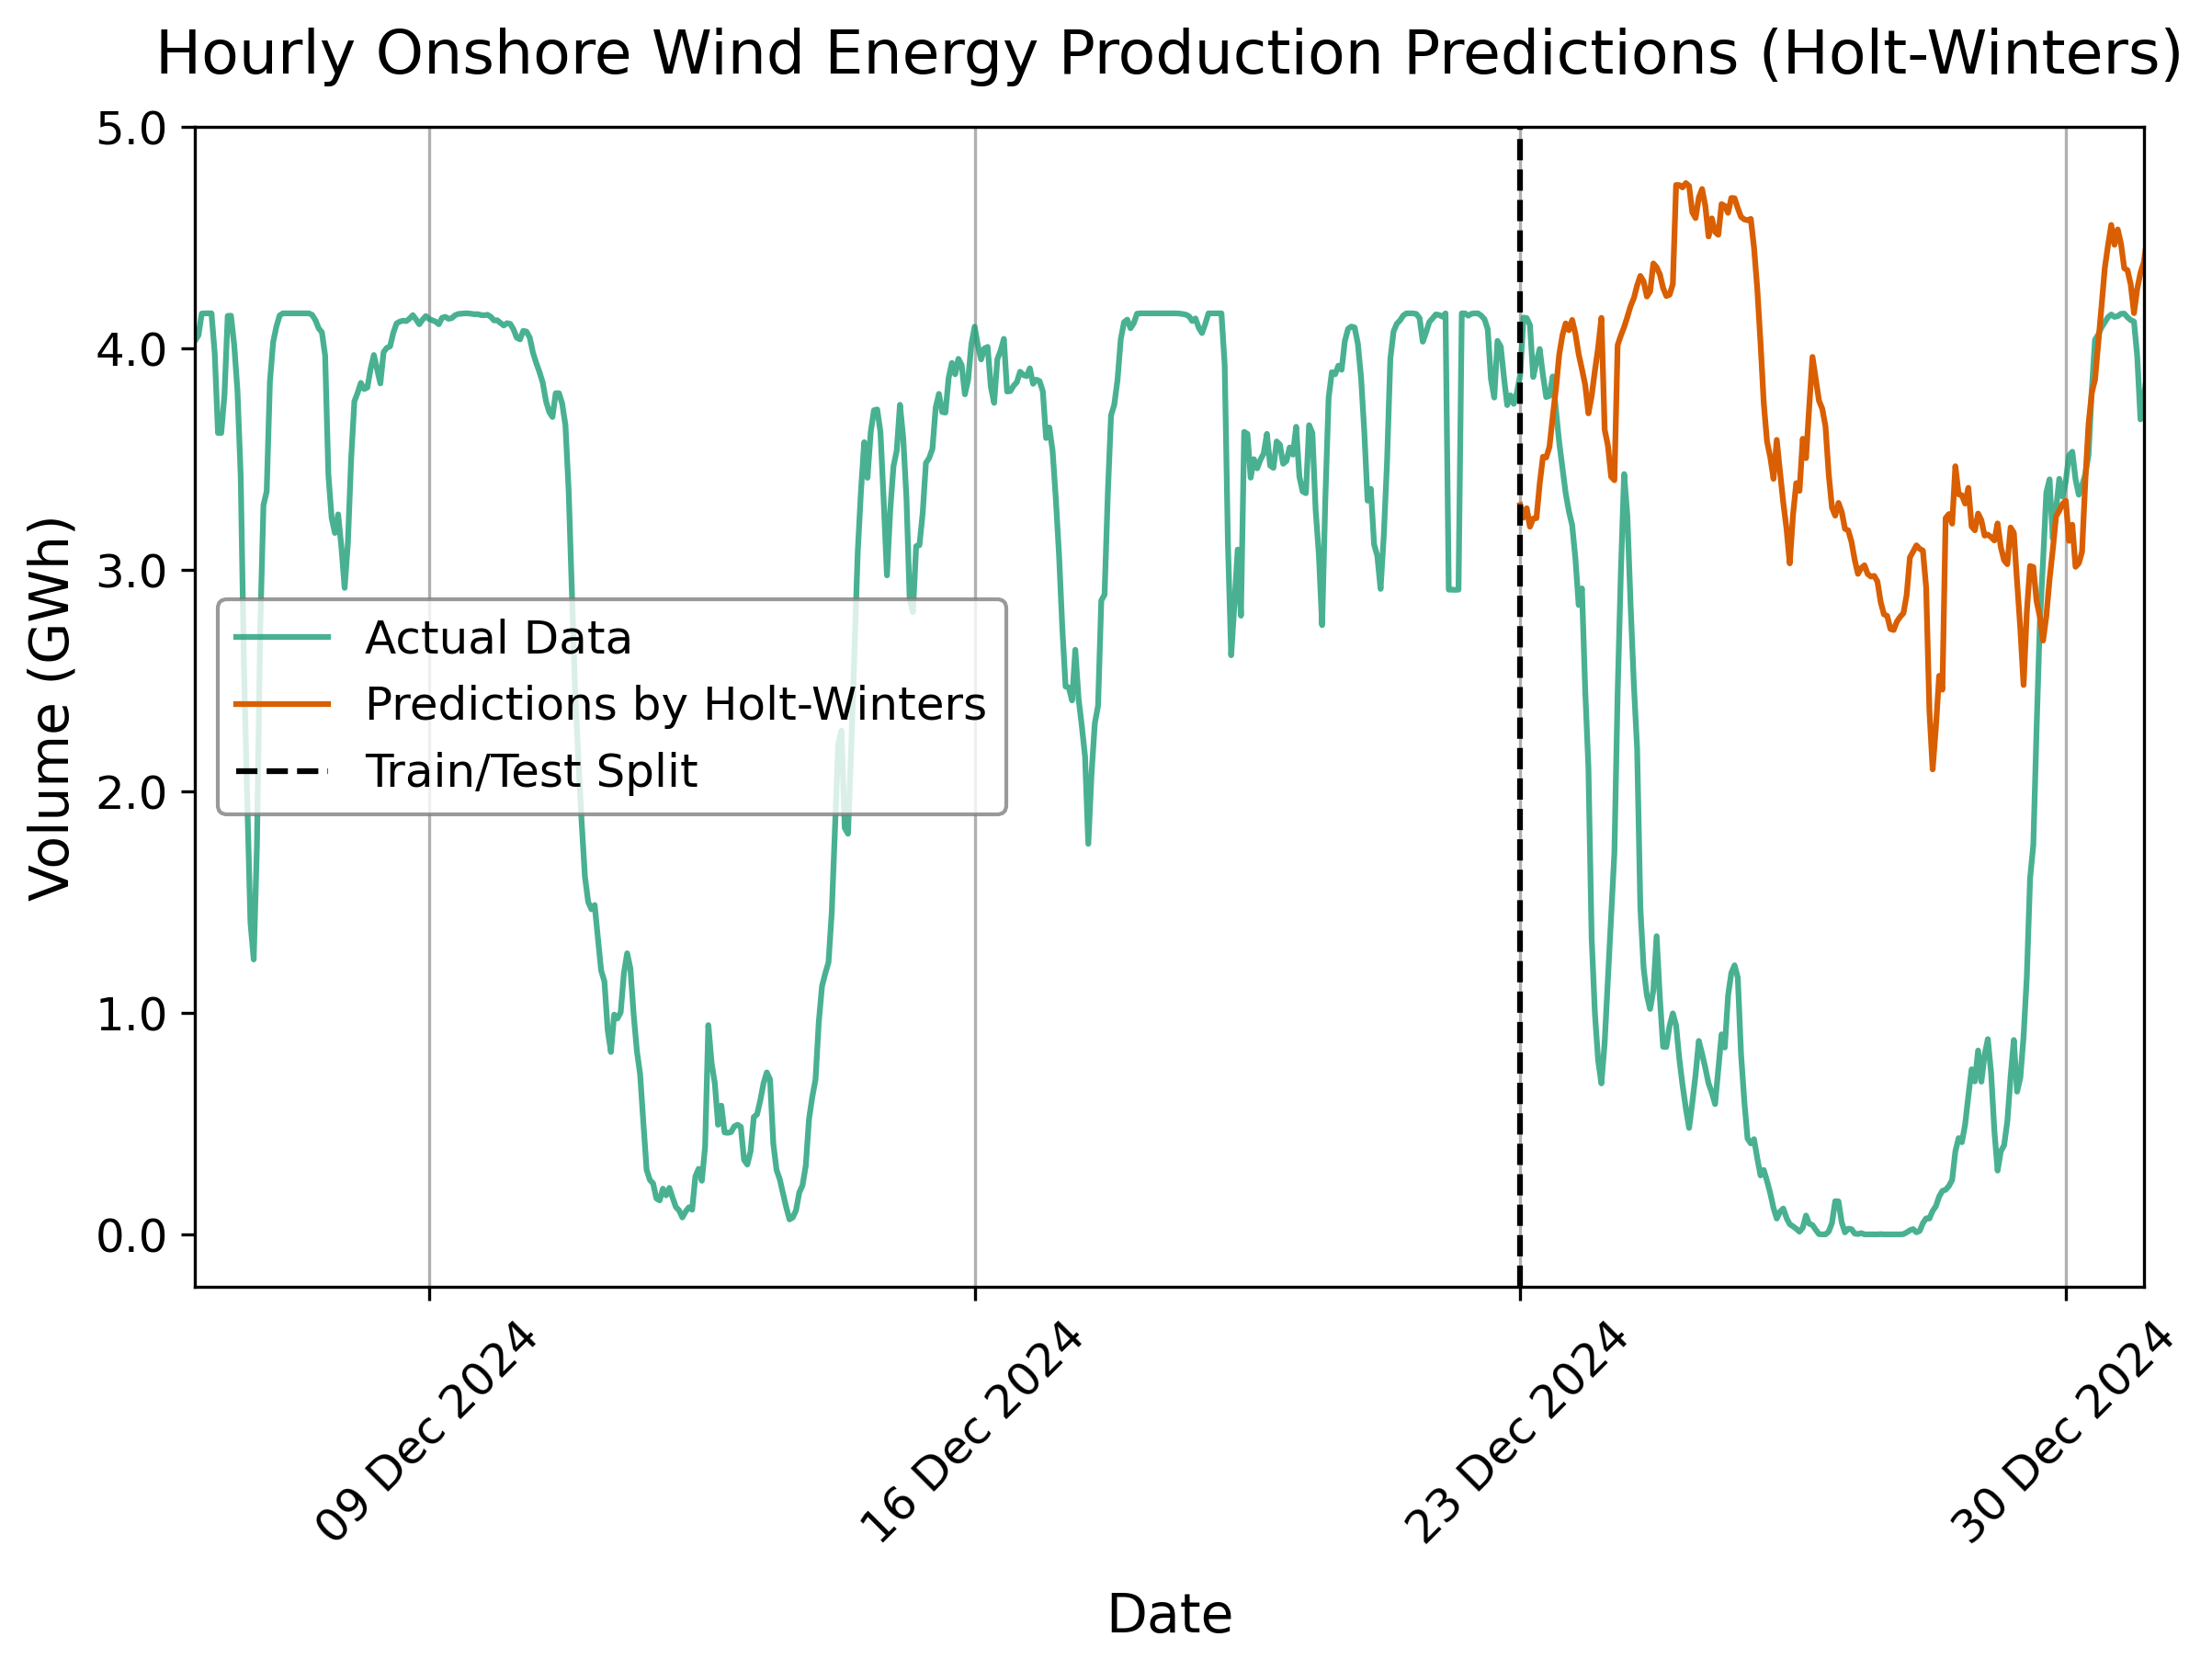

In [372]:
# Create figure with specific size and DPI
fig = plt.figure(figsize=(8, 6), dpi=300)
plt.plot(pd.to_datetime(db_on_hourly.index), db_on_hourly['volume'], label='Actual Data', color='#1b9e77', alpha=0.8)
plt.plot(pd.to_datetime(test_db_h_on.index), final_forecast, label='Predictions by Holt-Winters', color='#d95f02')
split_date = pd.to_datetime(test_db_h_on.index[0], format='%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Hourly Onshore Wind Energy Production Predictions (Holt-Winters)', pad=14, size=16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis='x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xlim(pd.to_datetime('2024-12-06'), pd.to_datetime('2024-12-31')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)

# Use tight layout with specified padding - this approximates bbox_inches='tight'
plt.tight_layout(pad=0.5)  # Adjust padding as needed

plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha=0.8)

# Display the figure
plt.show()

### SARIMAX models

#### Offshore data

In [373]:
def fit_predict_plot_sarimax(train_db, test_db, target_var, exclude_cols=None,
                             order=(3,1,0), seasonal_periods=12):
    if exclude_cols is None:
        exclude_cols = []

    # 1. Prepare exogenous variables
    drop_cols = [col for col in [target_var] + exclude_cols if col in train_db.columns]
    exog_vars = train_db.columns.drop(drop_cols)
    exog_feature_names = exog_vars.tolist()

    scaler = StandardScaler()
    train_exog_scaled = scaler.fit_transform(train_db[exog_vars])
    test_exog_scaled = scaler.transform(test_db[exog_vars])

    # 2. Define seasonal_order based on provided seasonal_periods
    seasonal_order = (1, 1, 1, seasonal_periods)

    # 3. Fit SARIMAX model
    model = SARIMAX(
        train_db[target_var],
        exog=train_exog_scaled,
        order=order,
        seasonal_order=seasonal_order
    )
    model_fit = model.fit(disp=True)

    # 4. Get t-statistics of exogenous coefficients
    exog_coeffs = model_fit.params[model_fit.model.exog_names]
    exog_t_stats = (exog_coeffs / model_fit.bse[model_fit.model.exog_names]).sort_values(ascending=False)

    # 5. Make predictions
    predictions = model_fit.predict(
        start=len(train_db[target_var]),
        end=len(train_db[target_var]) + len(test_db[target_var]) - 1,
        exog=test_exog_scaled,
        dynamic=False
    )

    # 6. Plot results
    plt.figure(figsize=(18,5))
    plt.plot(train_db[target_var], label="Train")
    plt.plot(test_db[target_var], label="Actual", color='red')
    plt.plot(predictions, label="Predicted", color='green')
    plt.legend()
    plt.title(f"SARIMAX Forecast vs Actual Volume (Seasonal Periods: {seasonal_periods})")
    plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
    plt.show()

    # 7. Print MSE
    mse = mean_squared_error(test_db[target_var], predictions)
    rmse = np.sqrt(mse)
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

    return model_fit, predictions, exog_t_stats

##### Monthly data

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.15893D+01    |proj g|=  6.44090D-02

At iterate    1    f=  1.15793D+01    |proj g|=  5.57395D-02

At iterate    2    f=  1.15734D+01    |proj g|=  3.52573D-02

At iterate    3    f=  1.15657D+01    |proj g|=  4.02772D-02

At iterate    4    f=  1.15598D+01    |proj g|=  2.93222D-02

At iterate    5    f=  1.15578D+01    |proj g|=  1.48950D-02

At iterate    6    f=  1.15575D+01    |proj g|=  4.12842D-03

At iterate    7    f=  1.15574D+01    |proj g|=  1.82449D-03

At iterate    8    f=  1.15574D+01    |proj g|=  2.93036D-03

At iterate    9    f=  1.15573D+01    |proj g|=  4.11862D-03

At iterate   10    f=  1.15572D+01    |proj g|=  7.59139D-03

At iterate   11    f=  1.15569D+01    |proj g|=  1.30496D-02

At iterate   12    f=  1.15566D+01    |proj g|=  1.17857D-02

At iterate   13    f=  1.1

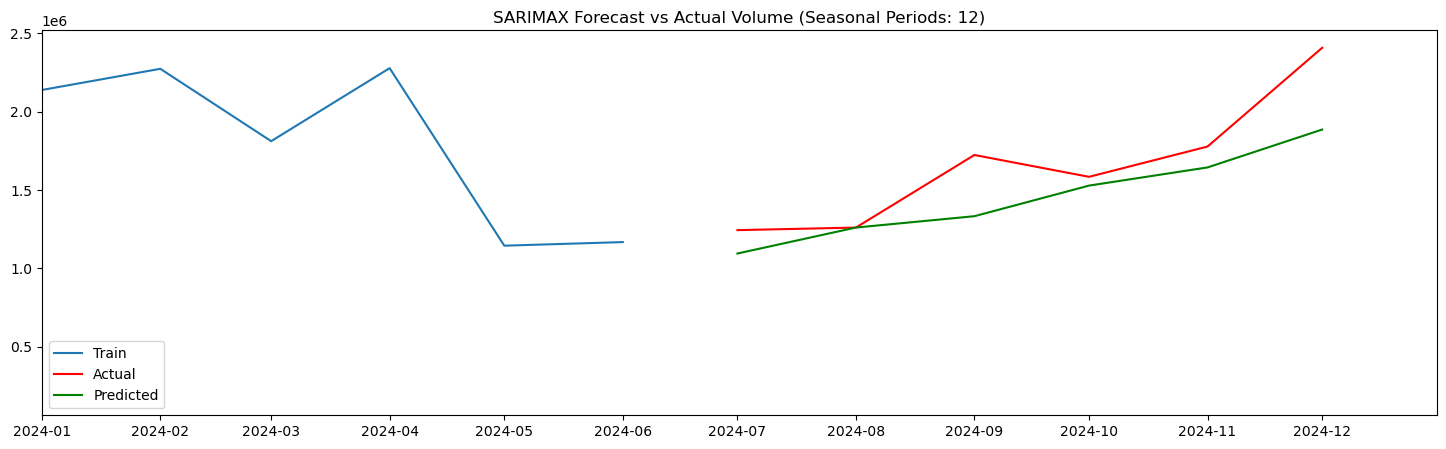

Mean Squared Error (MSE): 77913594569.39
Root Mean Squared Error (RMSE): 279130.07


In [374]:
model_fit_m_off, predictions_m_off, t_stats_m_off = fit_predict_plot_sarimax(
    train_db=train_db_m_off,
    test_db=test_db_m_off,
    target_var='volume',
    exclude_cols=['capacity', 'week_number', 'percentage', 'wind_speed_avg_10'],
    order=(3,1,1),
    seasonal_periods=12
)

##### Weekly data

In [375]:
# Retrieve exogenous variables
exog_vars = train_db_w_off.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_w = scaler.fit_transform(train_db_w_off[exog_vars])
test_exog_scaled_w = scaler.transform(test_db_w_off[exog_vars])

# Fit the model
model = SARIMAX(
        train_db_w_off['volume'], 
        exog=train_exog_scaled_w,
        order=(3,1,0),  # ARIMA components
        seasonal_order=(1,1,1,52)  # Seasonal components
    )
model_fit = model.fit(disp=True)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           10     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.20264D+01    |proj g|=  8.49997D-02

At iterate    1    f=  1.20147D+01    |proj g|=  5.97364D-02

At iterate    2    f=  1.20094D+01    |proj g|=  3.08715D-02

At iterate    3    f=  1.20041D+01    |proj g|=  4.03350D-02

At iterate    4    f=  1.19971D+01    |proj g|=  2.07036D-02

At iterate    5    f=  1.19965D+01    |proj g|=  1.13083D-02

At iterate    6    f=  1.19963D+01    |proj g|=  4.00494D-03

At iterate    7    f=  1.19962D+01    |proj g|=  4.17392D-04

At iterate    8    f=  1.19962D+01    |proj g|=  1.54612D-04

At iterate    9    f=  1.19962D+01    |proj g|=  2.96939D-05

At iterate   10    f=  1.19962D+01    |proj g|=  8.18190D-06

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

In [376]:
exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

x2    14.772506
x3     1.071440
x1     0.551832
x4     0.021012
dtype: float64

In [377]:
# Predict
predictions = model_fit.predict(
    start=len(train_db_w_off['volume']), 
    end=len(train_db_w_off['volume']) + len(test_db_w_off['volume']) - 1, 
    exog=test_exog_scaled_w, 
    dynamic=False)

In [378]:
# Plot predictions
plt.figure(figsize=(18,5))
#plt.plot(train_db_w['volume'], label="Train")
#plt.plot(test_db_w['volume'], label="Actual", color='red')
#plt.plot(predictions, label="Predicted", color='green')
#plt.legend()
#plt.title("SARIMAX Forecast vs Actual Volume")
#plt.show()

# Filter 2024 data
#train_subset = train_db_w_off[train_db_w_off.index >= 300]
#test_subset = test_db_w_off[test_db_w_off.index >= 300]
##pred_subset = predictions[predictions.index >= 300]

#plt.plot(train_subset['volume'], label="Train")
#plt.plot(test_subset['volume'], label="Actual", color='red')
#plt.plot(pred_subset, label="Predicted", color='green')

#plt.legend()
#plt.title("SARIMAX Forecast vs Actual Volume (2024)")
#plt.show()

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

In [379]:
# Compute MSE and RMSE
mse = mean_squared_error(test_db_w_off['volume'], predictions)
print(f'Mean Squared Error (MSE): {mse:.2f}')
rmse = np.sqrt(mean_squared_error(test_db_w_off['volume'], predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Squared Error (MSE): 464234948600.02
Root Mean Squared Error (RMSE): 681347.89


##### Daily data

In [380]:
# Retrieve exogenous variables
exog_vars = train_db_d_off.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity', 'week_number'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_d = scaler.fit_transform(train_db_d_off[exog_vars])
test_exog_scaled_d = scaler.transform(test_db_d_off[exog_vars])

# Alternative approach: 
stl = STL(train_db_d_off['volume'], period=365)
result = stl.fit()
train_db_d_off['deseasonalized'] = train_db_d_off['volume'] - result.seasonal

# Now apply SARIMA to deseasonalized data
model = SARIMAX(
        train_db_d_off['deseasonalized'], 
        exog=train_exog_scaled_d,
        order=(3,1,0),
        seasonal_order=(1,1,1,30)
  )  # Use a smaller seasonal period like 30 (monthly) if needed

model_fit = model.fit(disp=True)

/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_92598/813568572.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_db_d_off['deseasonalized'] = train_db_d_off['volume'] - result.seasonal
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.39397D+01    |proj g|=  7.18838D-02


 This problem is unconstrained.



At iterate    1    f=  1.39194D+01    |proj g|=  1.33047D-01

At iterate    2    f=  1.38949D+01    |proj g|=  6.62737D-02

At iterate    3    f=  1.38907D+01    |proj g|=  3.22981D-02

At iterate    4    f=  1.38880D+01    |proj g|=  8.64758D-03

At iterate    5    f=  1.38873D+01    |proj g|=  8.94438D-03

At iterate    6    f=  1.38861D+01    |proj g|=  9.61281D-03

At iterate    7    f=  1.38857D+01    |proj g|=  7.99587D-03

At iterate    8    f=  1.38854D+01    |proj g|=  2.84048D-03

At iterate    9    f=  1.38854D+01    |proj g|=  6.33424D-04

At iterate   10    f=  1.38854D+01    |proj g|=  3.30087D-04

At iterate   11    f=  1.38854D+01    |proj g|=  9.55881D-05

At iterate   12    f=  1.38854D+01    |proj g|=  1.33552D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized 

In [381]:
exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

x2    9.838754
x5    9.689689
x4   -0.140652
x3   -0.163608
x1   -0.842258
dtype: float64

In [382]:
# Predict 
predictions = model_fit.predict(
    start=len(train_db_d_off['volume']), 
    end=len(train_db_d_off['volume']) + len(test_db_d_off['volume']) - 1, 
    exog=test_exog_scaled_d, 
    dynamic=False)

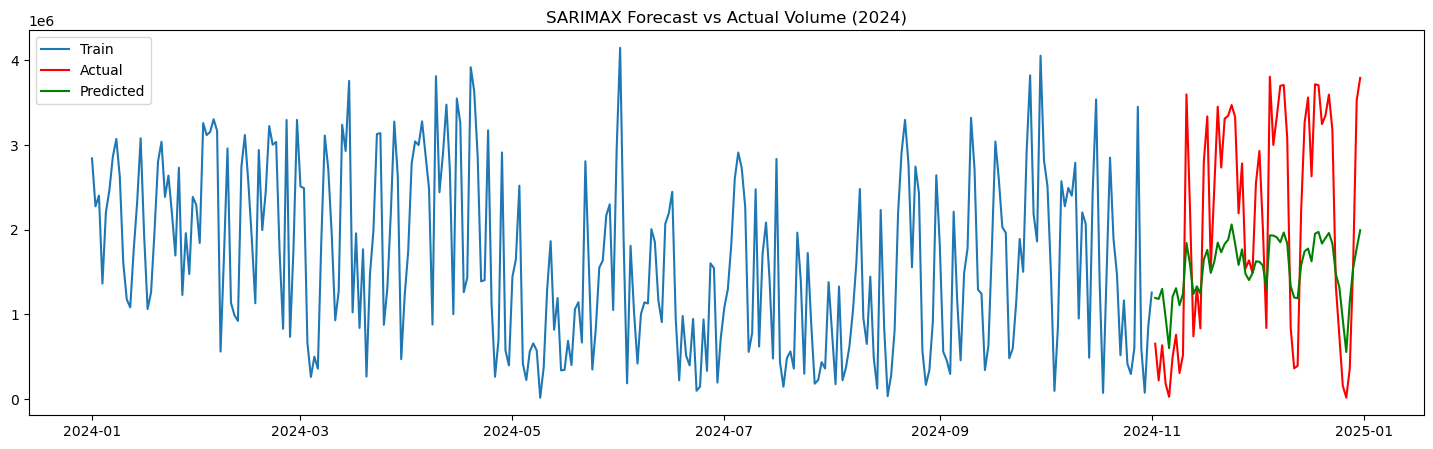

In [383]:
# Plot predictions
plt.figure(figsize=(18,5))

# Filter 2024 data
train_subset = train_db_d_off[train_db_d_off.index >= "2024-01-01"]
test_subset = test_db_d_off[test_db_d_off.index >= "2024-01-01"]
pred_subset = predictions[predictions.index >= "2024-01-01"]

plt.plot(train_subset['volume'], label="Train")
plt.plot(test_subset['volume'], label="Actual", color='red')
plt.plot(pred_subset, label="Predicted", color='green')

plt.legend()
plt.title("SARIMAX Forecast vs Actual Volume (2024)")
plt.show()

In [384]:
# Compute MSE and RMSE
mse = mean_squared_error(test_db_d_off['volume'], predictions)
print(f'Mean Squared Error (MSE): {mse:.2f}')
rmse = np.sqrt(mean_squared_error(test_db_d_off['volume'], predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Squared Error (MSE): 1261971182025.18
Root Mean Squared Error (RMSE): 1123374.91


#### Onshore data

##### Monthly data

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.16396D+01    |proj g|=  6.33327D-02

At iterate    1    f=  1.16336D+01    |proj g|=  4.91797D-02

At iterate    2    f=  1.16299D+01    |proj g|=  4.14406D-02

At iterate    3    f=  1.16137D+01    |proj g|=  5.09831D-02

At iterate    4    f=  1.16092D+01    |proj g|=  3.05290D-02

At iterate    5    f=  1.16079D+01    |proj g|=  8.86151D-03

At iterate    6    f=  1.16078D+01    |proj g|=  1.88001D-03

At iterate    7    f=  1.16077D+01    |proj g|=  3.38306D-04


/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.



At iterate    8    f=  1.16077D+01    |proj g|=  3.44391D-05

At iterate    9    f=  1.16077D+01    |proj g|=  1.79609D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   11      9     11      1     0     0   1.796D-05   1.161D+01
  F =   11.607745695306370     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


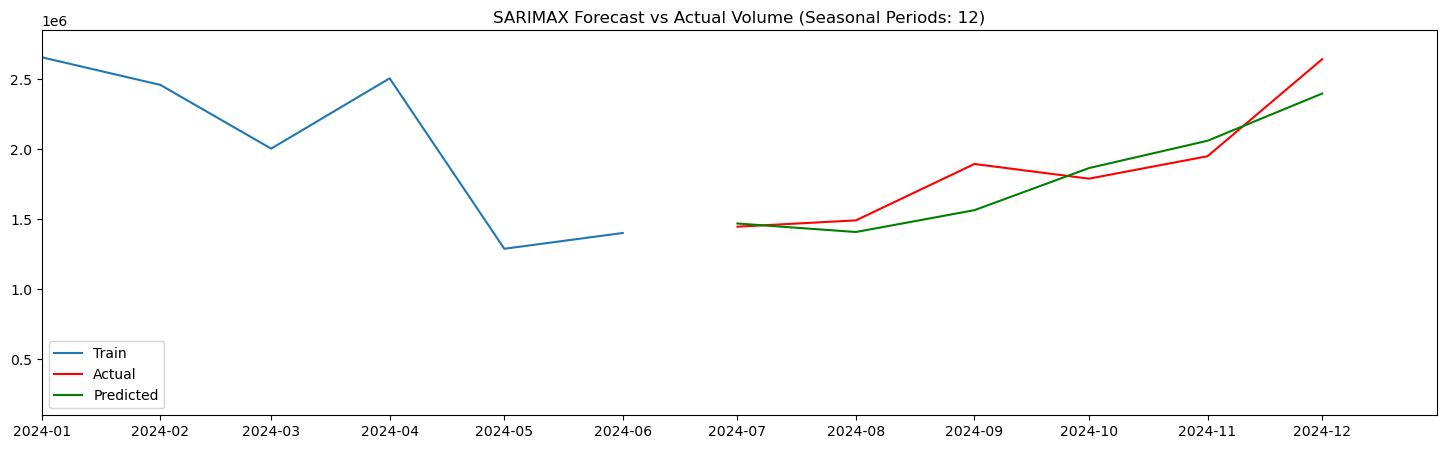

Mean Squared Error (MSE): 32333253713.67
Root Mean Squared Error (RMSE): 179814.50


In [385]:
model_fit_m_on, predictions_m_on, t_stats_m_on = fit_predict_plot_sarimax(
    train_db=train_db_m_on,
    test_db=test_db_m_on,
    target_var='volume',
    exclude_cols=['capacity', 'week_number', 'percentage', 'wind_speed_avg_10'],
    order=(3,1,1),
    seasonal_periods=12
)

##### Weekly data

In [386]:
# Retrieve exogenous variables
exog_vars = train_db_w_on.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_w = scaler.fit_transform(train_db_w_on[exog_vars])
test_exog_scaled_w = scaler.transform(test_db_w_on[exog_vars])

# Fit the model
model = SARIMAX(
        train_db_w_on['volume'], 
        exog=train_exog_scaled_w,
        order=(3,1,0),  # ARIMA components
        seasonal_order=(1,1,1,52)  # Seasonal components
    )
model_fit = model.fit(disp=True)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           10     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.21132D+01    |proj g|=  7.87525D-02


 This problem is unconstrained.



At iterate    1    f=  1.21029D+01    |proj g|=  2.88852D-02

At iterate    2    f=  1.20991D+01    |proj g|=  3.45319D-02

At iterate    3    f=  1.20947D+01    |proj g|=  2.75247D-02

At iterate    4    f=  1.20927D+01    |proj g|=  2.32573D-02

At iterate    5    f=  1.20919D+01    |proj g|=  5.67266D-03

At iterate    6    f=  1.20919D+01    |proj g|=  1.18037D-03

At iterate    7    f=  1.20919D+01    |proj g|=  3.46141D-04

At iterate    8    f=  1.20919D+01    |proj g|=  1.26390D-04

At iterate    9    f=  1.20919D+01    |proj g|=  4.60124D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   10      9     11   

In [387]:
exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

x2    12.976498
x1     1.799837
x3     0.497379
x4    -0.317271
dtype: float64

In [388]:
# Predict
predictions = model_fit.predict(
    start=len(train_db_w_on['volume']), 
    end=len(train_db_w_on['volume']) + len(test_db_w_on['volume']) - 1, 
    exog=test_exog_scaled_w, 
    dynamic=False)

In [389]:
# Compute MSE and RMSE
mse = mean_squared_error(test_db_w_on['volume'], predictions)
print(f'Mean Squared Error (MSE): {mse:.2f}')
rmse = np.sqrt(mean_squared_error(test_db_w_on['volume'], predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Squared Error (MSE): 672257313167.62
Root Mean Squared Error (RMSE): 819912.99


##### Daily data

In [390]:
# Retrieve exogenous variables
exog_vars = train_db_d_on.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity', 'week_number'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_d = scaler.fit_transform(train_db_d_on[exog_vars])
test_exog_scaled_d = scaler.transform(test_db_d_on[exog_vars])

# Alternative approach: 
stl = STL(train_db_d_on['volume'], period=365)
result = stl.fit()
train_db_d_on['deseasonalized'] = train_db_d_on['volume'] - result.seasonal

# Now apply SARIMA to deseasonalized data
model = SARIMAX(
        train_db_d_on['deseasonalized'], 
        exog=train_exog_scaled_d,
        order=(3,1,0),
        seasonal_order=(1,1,1,30)
  )  # Use a smaller seasonal period like 30 (monthly) if needed

model_fit = model.fit(disp=True)

/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_92598/253699471.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_db_d_on['deseasonalized'] = train_db_d_on['volume'] - result.seasonal
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           10     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.41141D+01    |proj g|=  7.27139D-02

At iterate    1    f=  1.40984D+01    |proj g|=  1.21222D-01

At iterate    2    f=  1.40751D+01    |proj g|=  7.38932D-02

At iterate    3    f=  1.40698D+01    |proj g|=  3.97143D-02

At iterate    4    f=  1.40663D+01    |proj g|=  1.47837D-02

At iterate    5    f=  1.40655D+01    |proj g|=  7.14698D-03

At iterate    6    f=  1.40648D+01    |proj g|=  5.64063D-03

At iterate    7    f=  1.40642D+01    |proj g|=  1.80087D-02

At iterate    8    f=  1.40635D+01    |proj g|=  1.99799D-03

At iterate    9    f=  1.40635D+01    |proj g|=  9.20034D-04

At iterate   10    f=  1.40634D+01    |proj g|=  2.55900D-04

At iterate   11    f=  1.40634D+01    |proj g|=  2.27044D-04

At iterate   12    f=  1.40634D+01    |proj g|=  2.78490D-05

At iterate   13    f=  1.4

In [391]:
exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

x2    19.309135
x1     0.198366
x3    -0.000283
x4    -0.425012
dtype: float64

In [392]:
# Predict 
predictions = model_fit.predict(
    start=len(train_db_d_on['volume']), 
    end=len(train_db_d_on['volume']) + len(test_db_d_on['volume']) - 1, 
    exog=test_exog_scaled_d, 
    dynamic=False)

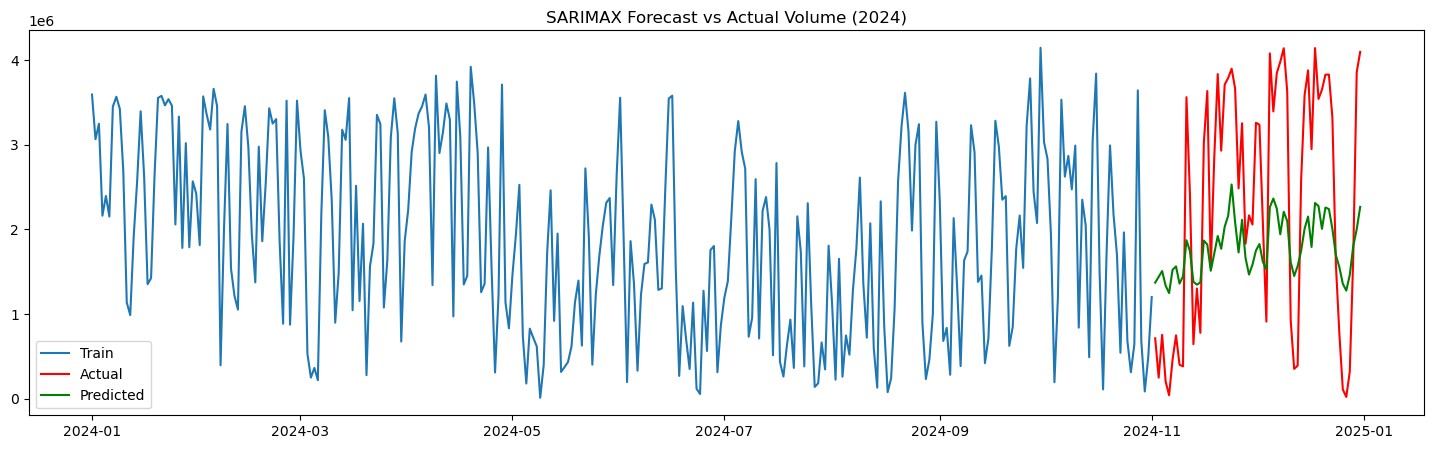

In [393]:
# Plot predictions
plt.figure(figsize=(18,5))

# Filter 2024 data
train_subset = train_db_d_on[train_db_d_on.index >= "2024-01-01"]
test_subset = test_db_d_on[test_db_d_on.index >= "2024-01-01"]
pred_subset = predictions[predictions.index >= "2024-01-01"]

plt.plot(train_subset['volume'], label="Train")
plt.plot(test_subset['volume'], label="Actual", color='red')
plt.plot(pred_subset, label="Predicted", color='green')

plt.legend()
plt.title("SARIMAX Forecast vs Actual Volume (2024)")
plt.show()

In [394]:
# Compute MSE and RMSE
mse = mean_squared_error(test_db_d_on['volume'], predictions)
print(f'Mean Squared Error (MSE): {mse:.2f}')
rmse = np.sqrt(mean_squared_error(test_db_d_on['volume'], predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Squared Error (MSE): 1589871769504.60
Root Mean Squared Error (RMSE): 1260901.17
